# Counterfactual explanations for MCI classification on NNConv model

**Strategy:**
1. **Node CF** - perturb volume + thickness per subject to flip the prediction. Analyse single subjects (TP/TN/FP/FN) and population averages per outcome group
2. **Edge CF** - freeze nodes at original values. Unfreeze only edges incident to the top-10 most-perturbed nodes, derived from node CF averaged over subjects *by predicted class* (MCI-predicted is one subgraph, CN-predicted is another). Perturb all 15 edge features on unfrozen edges

In [ ]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.1 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch_geometric.data import Data
from torch_geometric.nn import global_mean_pool, global_max_pool
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cuda


### Model definition

In [ ]:
class NNConvLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, out_dim):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, node_dim * out_dim)
        )
        self.node_dim = node_dim
        self.out_dim  = out_dim
        self.gru = nn.GRUCell(out_dim, node_dim)

    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        num_nodes = x.size(0)
        W     = self.edge_mlp(edge_attr).view(-1, self.node_dim, self.out_dim)
        h_src = x[src].unsqueeze(1)
        msg   = torch.bmm(h_src, W).squeeze(1)
        agg   = torch.zeros(num_nodes, self.out_dim, device=x.device)
        agg.scatter_add_(0, dst.unsqueeze(-1).expand_as(msg), msg)
        return self.gru(agg, x)


class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x = self.input_norm(x)
        x = x.relu()
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = x.relu()
        x = self.dropout(x)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        return self.classifier(x)

print('Model classes defined.')

Model classes defined.


### Load data and model

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/team3_xai_gnn/nnconv_results/outer_checkpoints/cfg00_outer1.pt'
TEST_PATH  = '/content/drive/MyDrive/team3_xai_gnn/preprocessed/fold_1_test.pt'
DMRI_PATH  = '/content/drive/MyDrive/team3_xai_gnn/oasis3_graphmls_scale1'

NODE_FEATURE_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']
EDGE_FEATURE_NAMES = [
    'number_of_fibers', 'fiber_length_mean', 'fiber_length_median',
    'fiber_length_std', 'fiber_proportion', 'normalized_fiber_density',
    'shore_gfa_mean', 'shore_gfa_std', 'shore_gfa_median',
    'shore_msd_mean', 'shore_msd_std', 'shore_msd_median',
    'shore_rtop_signal_mean', 'shore_rtop_signal_std', 'shore_rtop_signal_median'
]

OUTCOME_COLORS = {'TP': '#d62728', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#9467bd'}
CLASS_NAMES    = {0: 'CN', 1: 'MCI'}

model = NNConvNet(node_in=4, edge_in=15, hidden=32, dropout=0.3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print('Model loaded.')

Model loaded.


### Build map for node labels

In [ ]:
test_graphs = torch.load(TEST_PATH, map_location=device, weights_only=False)
print(f'Test subjects: {len(test_graphs)}')

# build node label map from one sample graphml
graphml_files = sorted([f for f in os.listdir(DMRI_PATH) if f.endswith('.graphml')])
sample_G      = nx.read_graphml(os.path.join(DMRI_PATH, graphml_files[0]))
sample_G.remove_edges_from(list(nx.selfloop_edges(sample_G)))
nodes       = list(sample_G.nodes(data=True))
node_labels = {i: attrs.get('dn_name', f'node_{i}').strip()
               for i, (_, attrs) in enumerate(nodes)}
print(f'Node label map built: {len(node_labels)} ROIs')

Test subjects: 127
Node label map built: 124 ROIs


### Find most confidently classified subjects per outcome

In [ ]:
def get_prediction(g):
    '''
    Returns (pred_class, prob_cn, prob_mci) for a single graph
    '''
    g     = g.to(device)
    batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(g.x, g.edge_index, g.edge_attr, batch)
        probs  = torch.softmax(logits, dim=-1)
        pred   = logits.argmax(dim=-1).item()
    return pred, probs[0, 0].item(), probs[0, 1].item()


# classify every test subject
all_results = []
for g in test_graphs:
    pred, prob_cn, prob_mci = get_prediction(g)
    true = g.y.item()
    all_results.append((g, true, pred, prob_mci))

TP = sorted([(g,t,p,s) for g,t,p,s in all_results if t==1 and p==1], key=lambda x: -x[3])
TN = sorted([(g,t,p,s) for g,t,p,s in all_results if t==0 and p==0], key=lambda x:  x[3])
FP = sorted([(g,t,p,s) for g,t,p,s in all_results if t==0 and p==1], key=lambda x: -x[3])
FN = sorted([(g,t,p,s) for g,t,p,s in all_results if t==1 and p==0], key=lambda x:  x[3])

print(f'TP: {len(TP)}  TN: {len(TN)}  FP: {len(FP)}  FN: {len(FN)}')
for tag, pool in [('TP',TP),('TN',TN),('FP',FP),('FN',FN)]:
    if pool:
        g,t,p,s = pool[0]
        print(f'  Most confident {tag}: {g.subject_id}  P(MCI)={s:.4f}')

TP: 14  TN: 87  FP: 18  FN: 8
  Most confident TP: OAS31004  P(MCI)=0.6972
  Most confident TN: OAS30723  P(MCI)=0.2792
  Most confident FP: OAS30443  P(MCI)=0.7888
  Most confident FN: OAS31050  P(MCI)=0.3662


## Stage 1
### Node Counterfactual

In [ ]:
def run_node_counterfactual(
    subject,
    target_class,
    lambda_prox = 0.5,
    lr          = 0.01,
    max_steps   = 500,
    patience    = 50,
):
    '''
    Finds a node-feature counterfactual for a single subject

    Only volume (col 0) and thickness (col 1) are perturbed
    has_volume and has_thickness (cols 2-3) are frozen throughout

    Returns
    dict with keys:
        x_cf         : counterfactual node features (num_nodes, 4)
        x_orig       : original node features (num_nodes, 4)
        delta        : x_cf - x_orig; only cols 0-1 are non-zero (num_nodes, 4)
        flipped      : bool — did the prediction flip?
        steps        : optimisation steps taken
        loss_history : total loss per step
        prob_history : P(target_class) per step
    '''
    subject = subject.to(device)
    batch   = torch.zeros(subject.x.size(0), dtype=torch.long, device=device)
    x_orig  = subject.x.clone().detach()           # (num_nodes, 4) - never modified

    # learnable perturbation on volume + thickness only
    delta_vt  = torch.zeros(x_orig.size(0), 2, device=device, requires_grad=True)
    optimiser = torch.optim.Adam([delta_vt], lr=lr)
    target_t  = torch.tensor([target_class], dtype=torch.long, device=device)

    loss_history, prob_history = [], []
    best_loss    = float('inf')
    patience_ctr = 0
    flipped      = False

    model.eval()
    for step in range(max_steps):
        optimiser.zero_grad()

        # build perturbed features - gradient flows through cat to delta_vt
        x_cf = torch.cat([
            x_orig[:, :2] + delta_vt,   # volume + thickness + perturbation
            x_orig[:, 2:],              # has_volume, has_thickness (frozen)
        ], dim=-1)

        logits = model(x_cf, subject.edge_index, subject.edge_attr, batch)
        probs  = torch.softmax(logits, dim=-1)

        l_pred = nn.functional.cross_entropy(logits, target_t)
        l_prox = (delta_vt ** 2).mean()               # MSE proximity on perturbed dims
        loss   = l_pred + lambda_prox * l_prox

        loss.backward()
        optimiser.step()

        loss_history.append(loss.item())
        prob_history.append(probs[0, target_class].item())

        pred_now = logits.argmax(dim=-1).item()
        if pred_now == target_class:
            flipped = True
            if loss.item() < best_loss - 1e-4:
                best_loss    = loss.item()
                patience_ctr = 0
            else:
                patience_ctr += 1
                if patience_ctr >= patience:
                    break
        else:
            best_loss    = loss.item()
            patience_ctr = 0

    with torch.no_grad():
        x_cf_final = torch.cat([
            x_orig[:, :2] + delta_vt,
            x_orig[:, 2:],
        ], dim=-1)
        delta_final = x_cf_final - x_orig

    return {
        'x_cf'         : x_cf_final.detach().cpu().numpy(),
        'x_orig'       : x_orig.cpu().numpy(),
        'delta'        : delta_final.detach().cpu().numpy(),
        'flipped'      : flipped,
        'steps'        : step + 1,
        'loss_history' : loss_history,
        'prob_history' : prob_history,
    }

print('Node CF function ready.')

Node CF function ready.


### Plotting helpers

In [ ]:
def node_delta_magnitude(delta):
    '''
    Sum of |Δ| over volume + thickness per node. Shape: (num_nodes,)
    '''
    return np.abs(delta[:, :2]).sum(axis=1)


def get_top_nodes(delta, top_n=10):
    '''
    Returns (top_indices, top_names, top_scores, all_scores)
    '''
    scores    = node_delta_magnitude(delta)
    top_idx   = np.argsort(scores)[::-1][:top_n]
    top_names = [node_labels[i] for i in top_idx]
    return top_idx, top_names, scores[top_idx], scores


def plot_convergence(ax, loss_history, prob_history, target_class, title):
    steps = range(len(loss_history))
    ax2   = ax.twinx()
    ax.plot(steps, loss_history, color='black', linewidth=1.2, label='Total loss')
    color = '#d62728' if target_class == 1 else '#1f77b4'
    ax2.plot(steps, prob_history, color=color, linewidth=1.2,
             linestyle='--', label=f'P({CLASS_NAMES[target_class]})')
    ax.set_xlabel('Optimisation step', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax2.set_ylabel(f'P({CLASS_NAMES[target_class]})', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)


def plot_node_delta_bar(ax, delta, title, color, top_n=10):
    top_idx, top_names, top_scores, _ = get_top_nodes(delta, top_n)
    names_r  = list(top_names[::-1])
    scores_r = list(top_scores[::-1])
    bars = ax.barh(names_r, scores_r, color=color, alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Total |Δ| (volume + thickness)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    for bar, score in zip(bars, scores_r):
        ax.text(bar.get_width() + max(scores_r) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)


def plot_node_feature_heatmap(ax, delta, title, top_n=10):
    top_idx, top_names, _, _ = get_top_nodes(delta, top_n)
    top_delta = delta[top_idx, :2]   # (top_n, 2)
    vmax = np.abs(top_delta).max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im   = ax.imshow(top_delta, cmap='RdBu_r', norm=norm, aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['volume', 'thickness'], fontsize=10)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8).set_label('Signed Δ', fontsize=9)
    for i in range(top_n):
        for j in range(2):
            val = top_delta[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > vmax * 0.6 else 'black')


def plot_orig_vs_cf_node(cf_result, tag, top_n=10):
    '''
    Grouped bar: original vs CF for top nodes, split by volume and thickness
    '''
    delta    = cf_result['delta']
    x_orig   = cf_result['x_orig']
    x_cf     = cf_result['x_cf']
    top_idx, top_names, _, _ = get_top_nodes(delta, top_n)
    c = OUTCOME_COLORS[tag]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, col, feat_name in [(axes[0], 0, 'Volume'), (axes[1], 1, 'Thickness')]:
        orig_vals = x_orig[top_idx, col][::-1]
        cf_vals   = x_cf[top_idx, col][::-1]
        names_r   = list(top_names[::-1])
        y_pos     = np.arange(top_n)
        height    = 0.35
        ax.barh(y_pos + height/2, orig_vals, height,
                label='Original', color='#888888', alpha=0.75,
                edgecolor='black', linewidth=0.5)
        ax.barh(y_pos - height/2, cf_vals, height,
                label='Counterfactual', color=c, alpha=0.85,
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(names_r, fontsize=8)
        ax.set_xlabel(f'{feat_name} (z-score)', fontsize=10)
        ax.set_title(f'{feat_name} - Original vs Counterfactual',
                     fontsize=11, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(fontsize=9)
        for i, (o, cv) in enumerate(zip(orig_vals, cf_vals)):
            dv = cv - o
            if abs(dv) > 1e-4:
                sign = '+' if dv > 0 else ''
                ax.text(max(o, cv) + 0.02, y_pos[i] - height/2 + height/4,
                        f'{sign}{dv:.3f}', va='center', fontsize=7)
    return fig


print('Node CF plotting helpers ready.')

Node CF plotting helpers ready.


### Most confidently classified subject per outcome analysis


--------------------------------------------------------------------------------

TP | OAS31004 | True: MCI | Pred: MCI | CF target: CN
  FLIPPED in 500 steps
  Final P(CN): 0.7982
  Top 10 most-perturbed ROIs:
    01. ctx-rh-caudalmiddlefrontal                    |Δ|=6.551474
    02. Right-Anterior                                |Δ|=3.060919
    03. Brain_Stem-Midbrain                           |Δ|=2.741522
    04. Right-Ventral_Latero_Ventral                  |Δ|=2.586803
    05. ctx-lh-postcentral                            |Δ|=2.550069
    06. ctx-lh-temporalpole                           |Δ|=1.918390
    07. ctx-lh-isthmuscingulate                       |Δ|=1.557776
    08. ctx-rh-entorhinal                             |Δ|=1.287792
    09. ctx-lh-caudalanteriorcingulate                |Δ|=1.116871
    10. ctx-lh-middletemporal                         |Δ|=1.013189


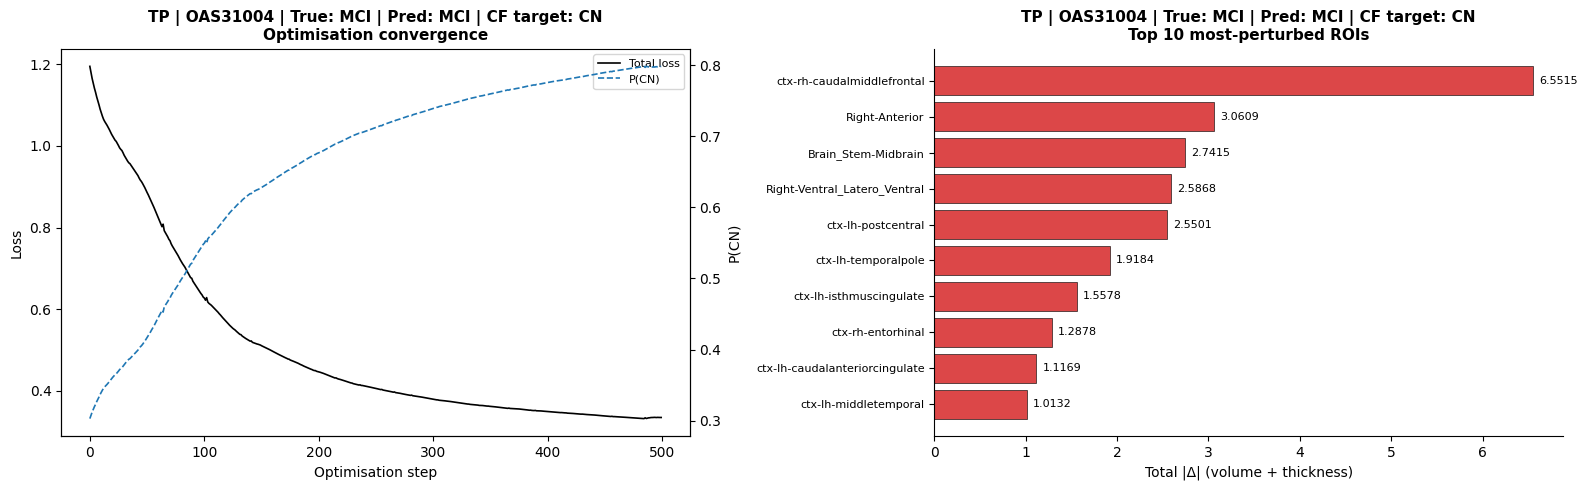

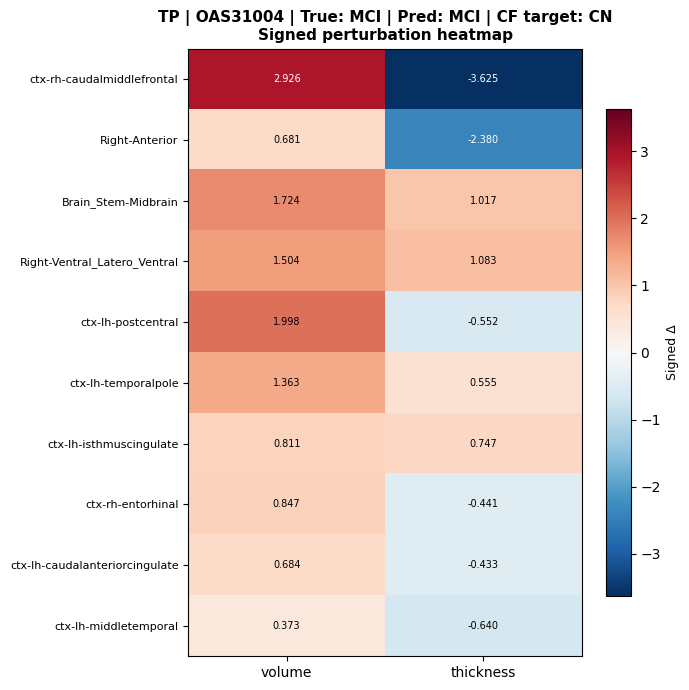

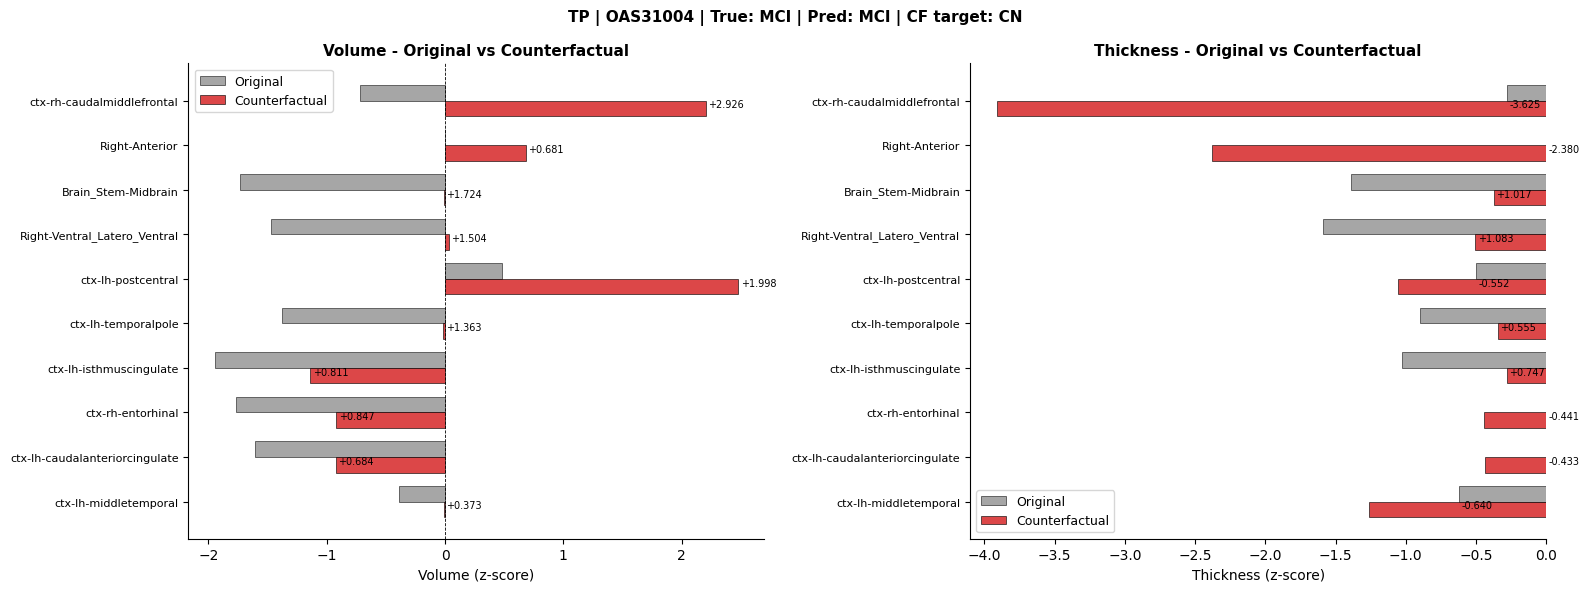


--------------------------------------------------------------------------------

TN | OAS30723 | True: CN | Pred: CN | CF target: MCI
  FLIPPED in 500 steps
  Final P(MCI): 0.6182
  Top 10 most-perturbed ROIs:
    01. ctx-rh-parsorbitalis                          |Δ|=7.738988
    02. Left-Hippocampus_Parasubiculum                |Δ|=4.770268
    03. Right-Medio_Dorsal                            |Δ|=2.648942
    04. ctx-rh-superiorparietal                       |Δ|=2.622688
    05. ctx-rh-parstriangularis                       |Δ|=2.419997
    06. Right-Ventral_Anterior                        |Δ|=2.306386
    07. ctx-lh-posteriorcingulate                     |Δ|=2.285866
    08. Left-Medio_Dorsal                             |Δ|=2.243801
    09. Left-Hippocampus_Hippocampal_fissure          |Δ|=2.017063
    10. ctx-rh-parahippocampal                        |Δ|=1.880320


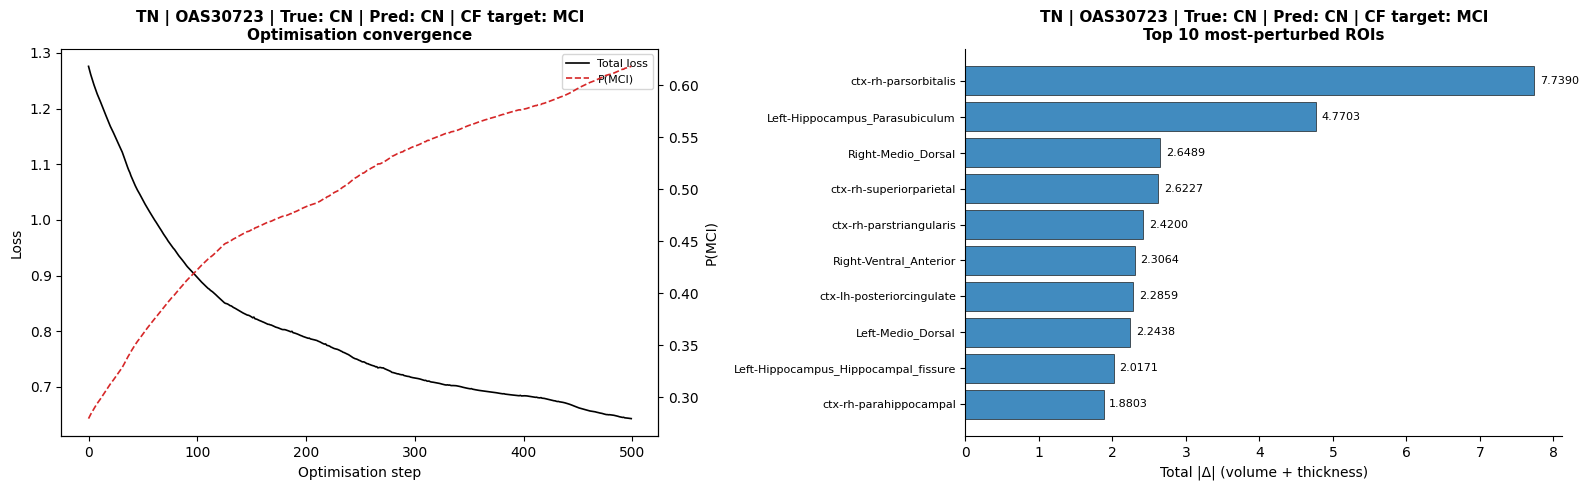

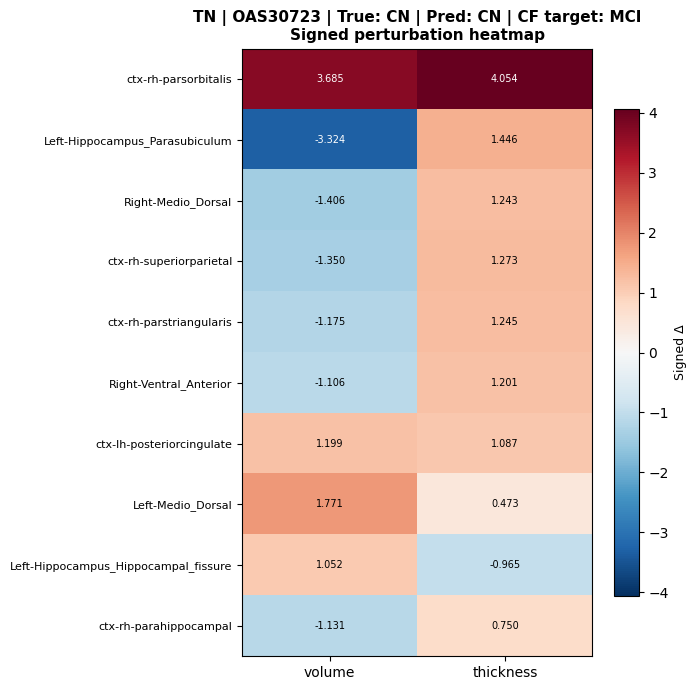

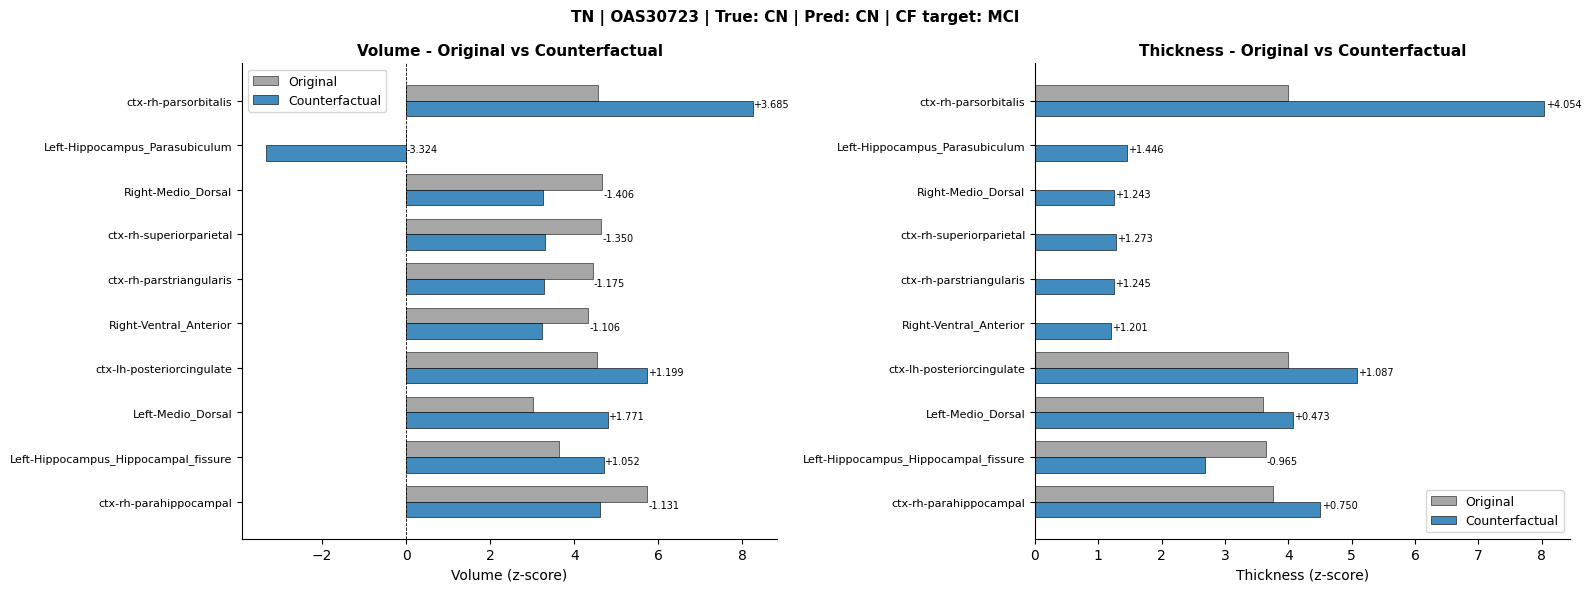


--------------------------------------------------------------------------------

FP | OAS30443 | True: CN | Pred: MCI | CF target: CN
  FLIPPED in 500 steps
  Final P(CN): 0.7995
  Top 10 most-perturbed ROIs:
    01. ctx-lh-parsopercularis                        |Δ|=8.537961
    02. ctx-rh-rostralanteriorcingulate               |Δ|=5.158357
    03. Right-Amygdala                                |Δ|=3.022820
    04. ctx-lh-parstriangularis                       |Δ|=2.026083
    05. Right-Hippocampus_Fimbria                     |Δ|=1.147824
    06. ctx-lh-entorhinal                             |Δ|=0.995021
    07. ctx-rh-caudalanteriorcingulate                |Δ|=0.960343
    08. Right-Pulvinar                                |Δ|=0.939417
    09. ctx-lh-rostralmiddlefrontal                   |Δ|=0.802624
    10. ctx-lh-lateraloccipital                       |Δ|=0.674345


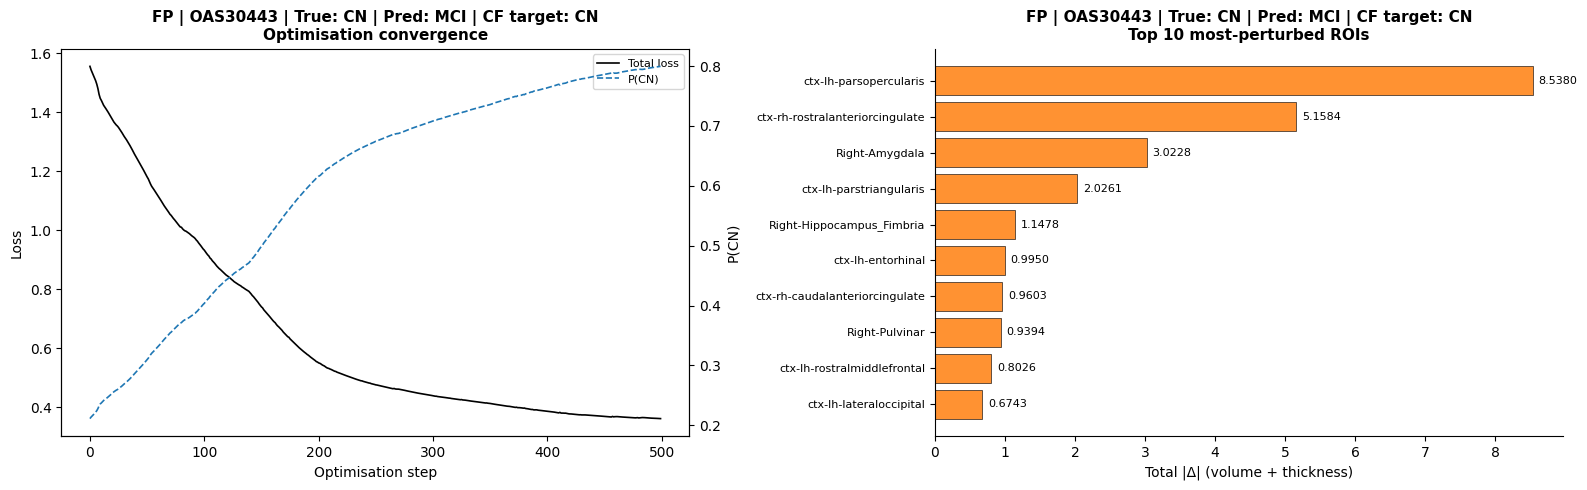

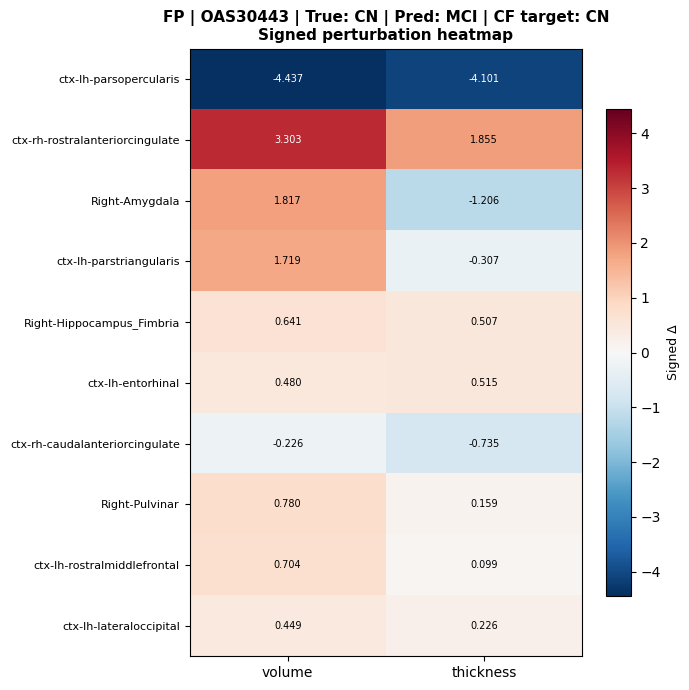

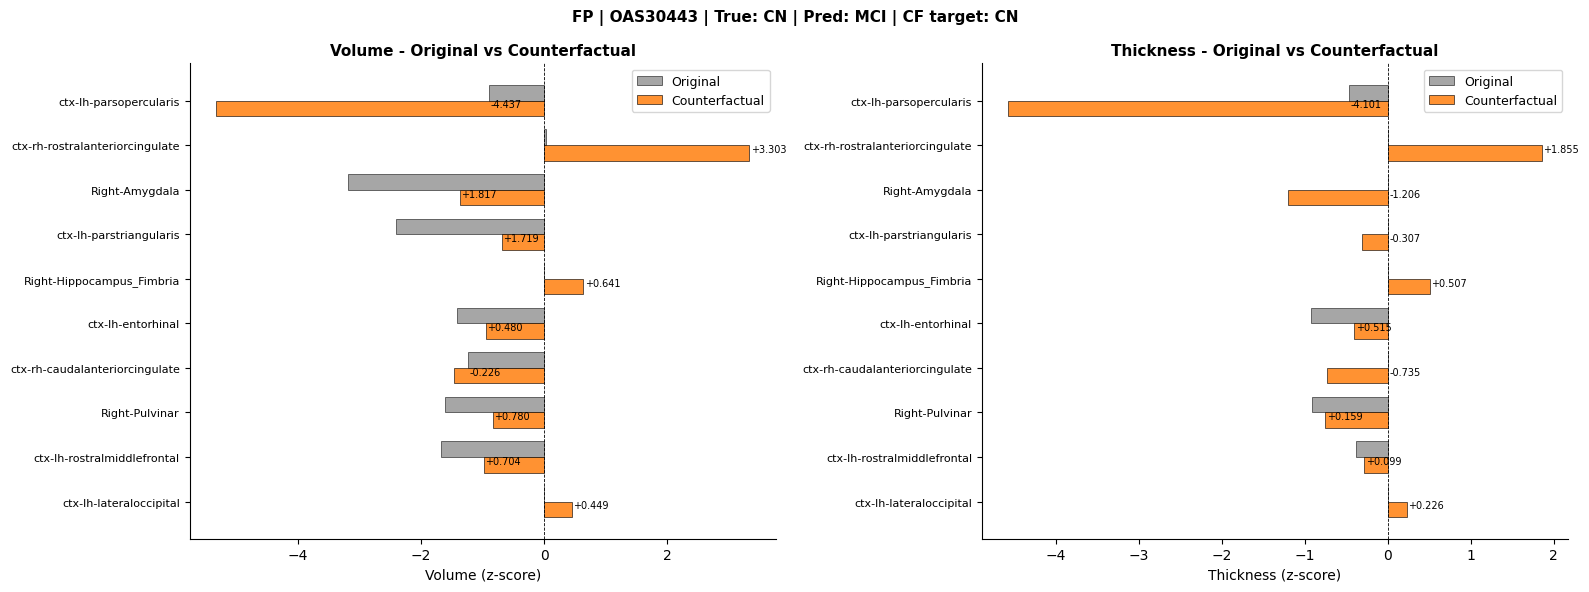


--------------------------------------------------------------------------------

FN | OAS31050 | True: MCI | Pred: CN | CF target: MCI
  FLIPPED in 500 steps
  Final P(MCI): 0.9130
  Top 10 most-perturbed ROIs:
    01. ctx-rh-fusiform                               |Δ|=4.515310
    02. ctx-rh-pericalcarine                          |Δ|=3.980584
    03. ctx-rh-superiorfrontal                        |Δ|=3.312238
    04. ctx-rh-isthmuscingulate                       |Δ|=2.197956
    05. Right-Central_Lateral-Lateral_Posterior-Medial_Pulvinar |Δ|=1.297400
    06. Right-Hippocampus_Hippocampal_fissure         |Δ|=1.107748
    07. ctx-lh-isthmuscingulate                       |Δ|=0.781984
    08. Left-VentralDC                                |Δ|=0.736531
    09. ctx-rh-paracentral                            |Δ|=0.700762
    10. ctx-lh-parstriangularis                       |Δ|=0.672333


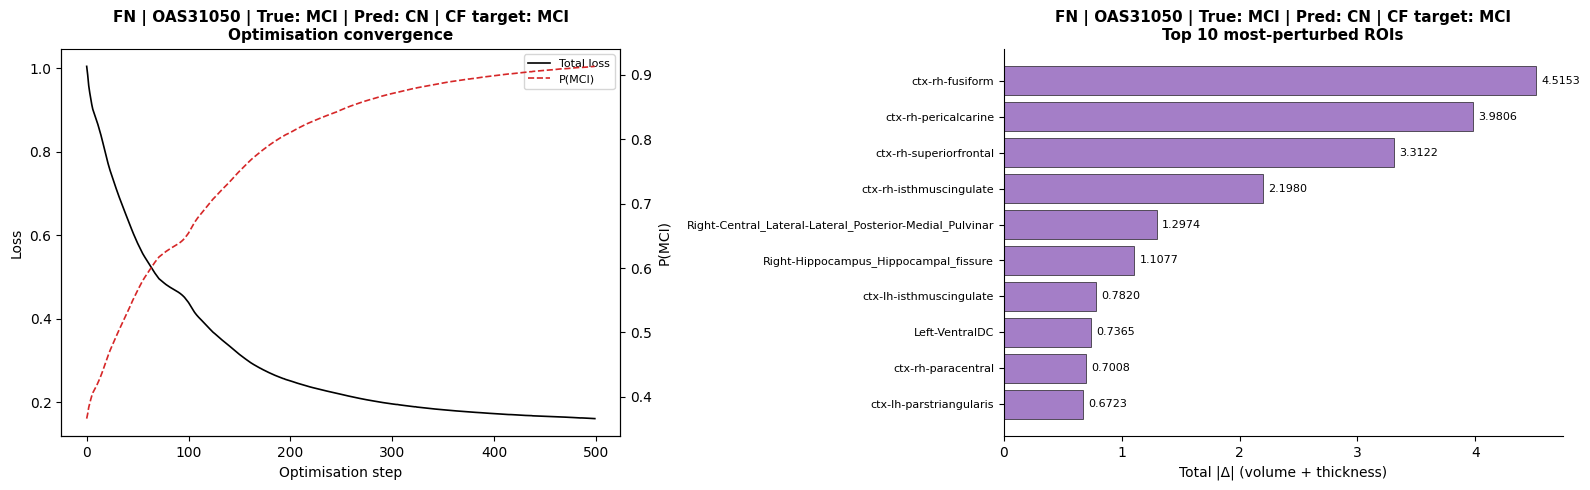

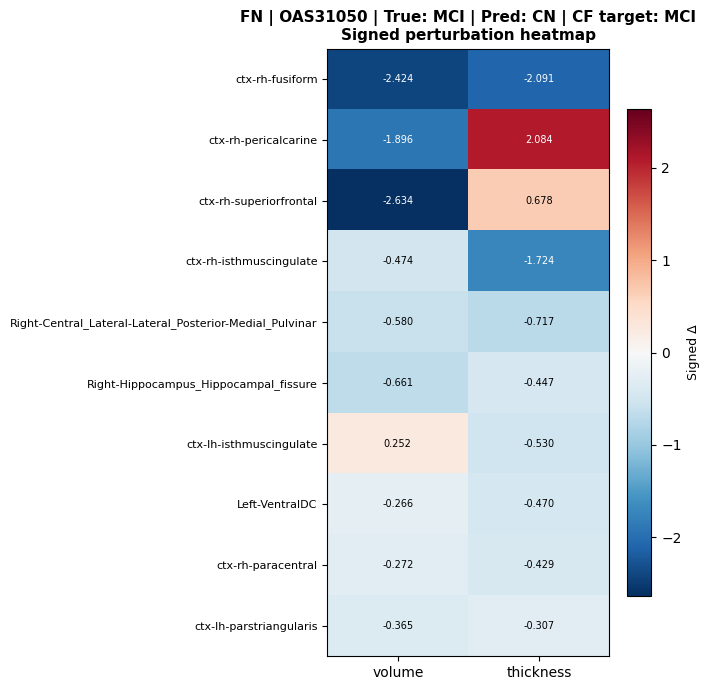

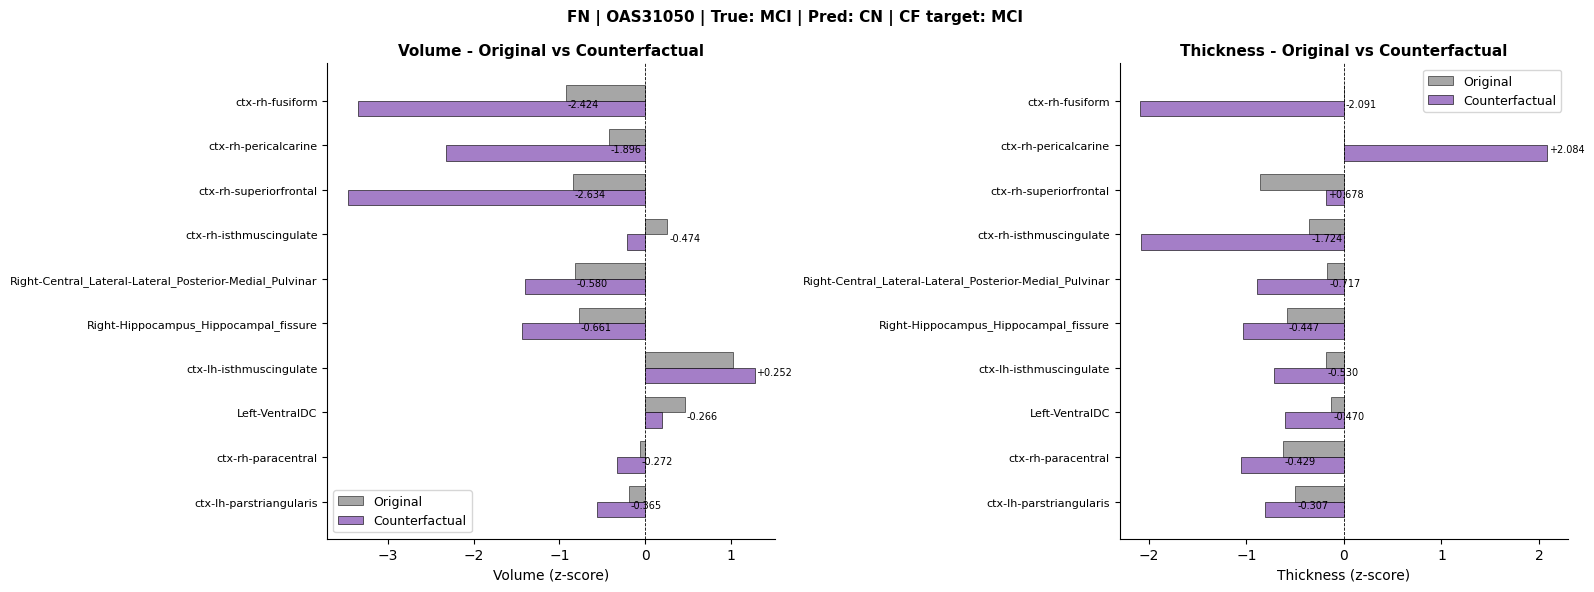

In [ ]:
def run_node_single_subject(g, true_l, pred_l, tag,
                             lambda_prox=0.5, lr=0.01, max_steps=500):
    target_class = 1 - pred_l
    cf = run_node_counterfactual(g, target_class,
                                  lambda_prox=lambda_prox, lr=lr, max_steps=max_steps)

    flipped_str = 'FLIPPED' if cf['flipped'] else 'NOT FLIPPED'
    title_base  = (f"{tag} | {g.subject_id} | "
                   f"True: {CLASS_NAMES[true_l]} | Pred: {CLASS_NAMES[pred_l]} | "
                   f"CF target: {CLASS_NAMES[target_class]}")
    print(f'\n{title_base}')
    print(f'  {flipped_str} in {cf["steps"]} steps')
    print(f'  Final P({CLASS_NAMES[target_class]}): {cf["prob_history"][-1]:.4f}')

    top_idx, top_names, top_scores, _ = get_top_nodes(cf['delta'])
    print('  Top 10 most-perturbed ROIs:')
    for rank, (name, score) in enumerate(zip(top_names, top_scores)):
        print(f'    {rank+1:02d}. {name:<45s} |Δ|={score:.6f}')

    c = OUTCOME_COLORS[tag]

    # figure 1: convergence + perturbation bar
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_convergence(axes[0], cf['loss_history'], cf['prob_history'],
                     target_class, f'{title_base}\nOptimisation convergence')
    plot_node_delta_bar(axes[1], cf['delta'],
                        f'{title_base}\nTop 10 most-perturbed ROIs', c)
    plt.tight_layout()
    plt.show()

    # figure 2: signed delta heatmap
    fig, ax = plt.subplots(figsize=(7, 7))
    plot_node_feature_heatmap(ax, cf['delta'],
                              f'{title_base}\nSigned perturbation heatmap')
    plt.tight_layout()
    plt.show()

    # figure 3: original vs CF grouped bars
    fig = plot_orig_vs_cf_node(cf, tag)
    fig.suptitle(title_base, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return cf


# run for most-confident subject in each outcome group
node_case_results = {}
for tag, pool in [('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN)]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    g, true_l, pred_l, _ = pool[0]
    print(f'\n{"-"*80}')
    cf = run_node_single_subject(g, true_l, pred_l, tag)
    node_case_results[tag] = {'graph': g, 'true': true_l, 'pred': pred_l, 'cf': cf}

### Population analysis per outcome group

In [ ]:
def run_node_cf_population(result_pool, pred_label, tag,
                            lambda_prox=0.5, lr=0.01, max_steps=500):
    '''
    Runs node CF on every subject in result_pool

    Returns
    mean_delta : (num_nodes,) mean absolute delta per node across population
    flip_rate  : fraction of subjects whose prediction flipped
    subject_cfs: dict {subject_id: cf_result} for downstream use
    '''
    target_class  = 1 - pred_label
    all_delta_mag = []
    subject_cfs   = {}
    flip_count    = 0

    for g, true, pred, prob_mci in result_pool:
        cf = run_node_counterfactual(
            g, target_class,
            lambda_prox=lambda_prox, lr=lr, max_steps=max_steps
        )
        all_delta_mag.append(node_delta_magnitude(cf['delta']))
        subject_cfs[g.subject_id] = cf
        if cf['flipped']:
            flip_count += 1

    mean_delta = np.stack(all_delta_mag).mean(axis=0)   # (num_nodes,)
    flip_rate  = flip_count / len(result_pool)
    print(f'{tag} (n={len(result_pool)}): flip rate = {flip_rate:.2%}')
    return mean_delta, flip_rate, subject_cfs


node_pop_results = {}
node_subject_cfs = {}

for tag, pool, pred_l in [('TP', TP, 1), ('TN', TN, 0), ('FP', FP, 1), ('FN', FN, 0)]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    mean_delta, flip_rate, subj_cfs = run_node_cf_population(pool, pred_l, tag)
    node_pop_results[tag] = {'mean_delta': mean_delta, 'flip_rate': flip_rate, 'n': len(pool)}
    node_subject_cfs.update(subj_cfs)

TP (n=14): flip rate = 100.00%
TN (n=87): flip rate = 100.00%
FP (n=18): flip rate = 100.00%
FN (n=8): flip rate = 100.00%


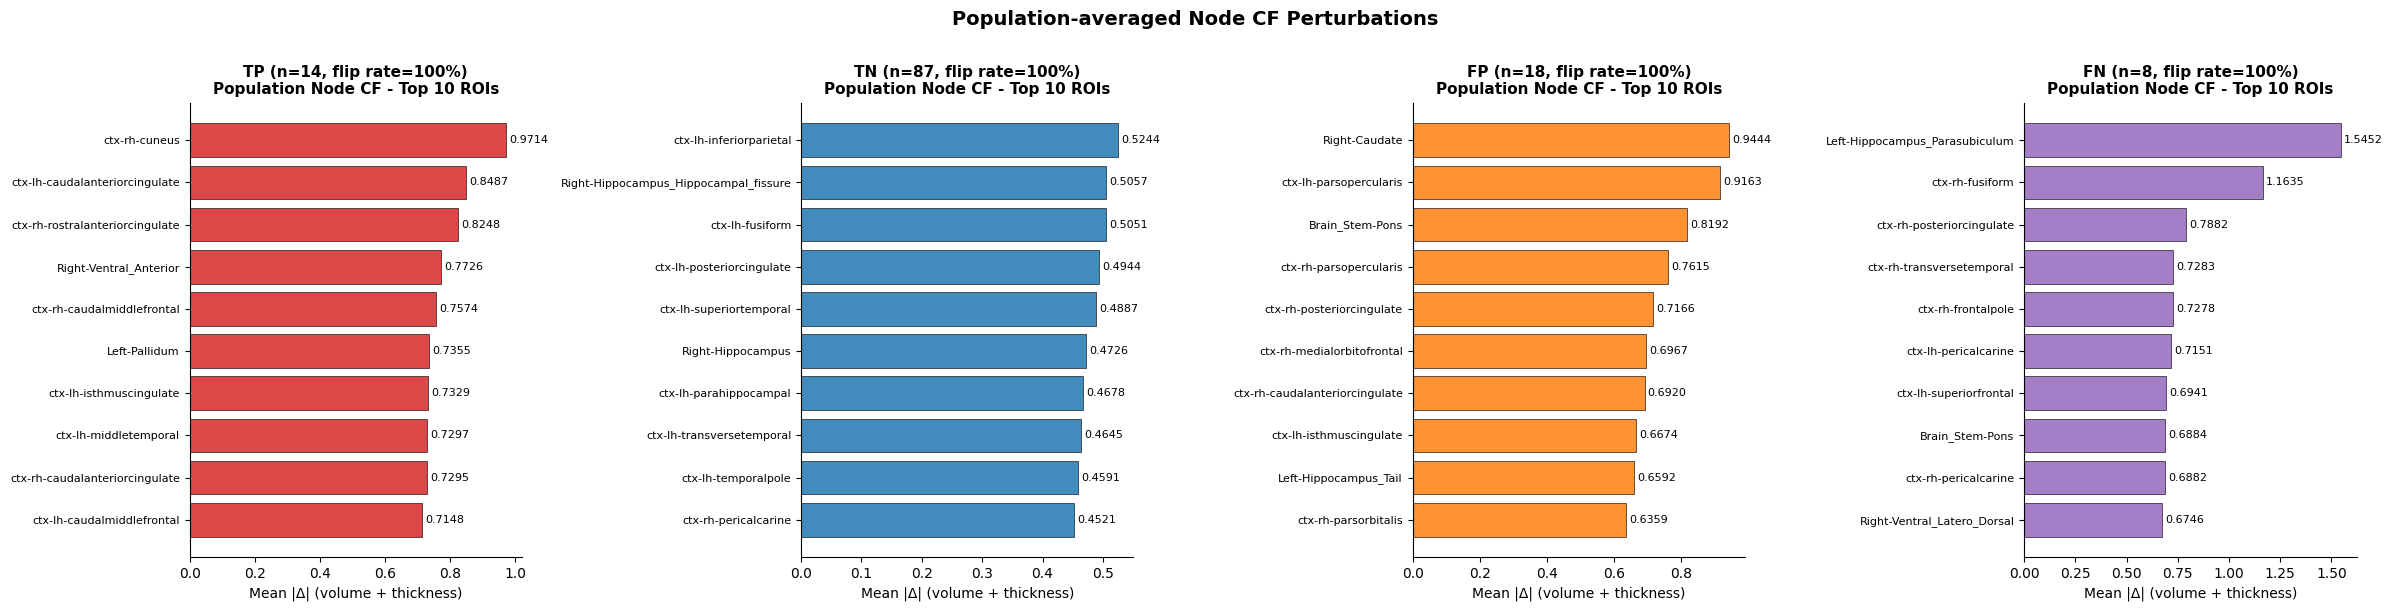


Node CF flip rate summary:
  TP (n=14): 100.00%
  TN (n=87): 100.00%
  FP (n=18): 100.00%
  FN (n=8): 100.00%


In [ ]:
# population bar charts — one panel per outcome group
available_tags = [t for t in ['TP', 'TN', 'FP', 'FN'] if t in node_pop_results]
fig, axes = plt.subplots(1, len(available_tags), figsize=(6 * len(available_tags), 6))
if len(available_tags) == 1:
    axes = [axes]

for ax, tag in zip(axes, available_tags):
    r = node_pop_results[tag]
    # build a fake delta array shaped (num_nodes, 4) so plot_node_delta_bar works
    fake_delta = np.zeros((len(node_labels), 4))
    fake_delta[:, 0] = r['mean_delta']   # treat mean_delta as column 0 for plotting
    # we override the ylabel manually
    top_idx = np.argsort(r['mean_delta'])[::-1][:10]
    top_scores = r['mean_delta'][top_idx]
    top_names  = [node_labels[i] for i in top_idx]
    names_r  = list(top_names[::-1])
    scores_r = list(top_scores[::-1])
    bars = ax.barh(names_r, scores_r, color=OUTCOME_COLORS[tag], alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Mean |Δ| (volume + thickness)', fontsize=10)
    ax.set_title(f"{tag} (n={r['n']}, flip rate={r['flip_rate']:.0%})\nPopulation Node CF - Top 10 ROIs",
                 fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    for bar, score in zip(bars, scores_r):
        ax.text(bar.get_width() + max(scores_r) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)

plt.suptitle('Population-averaged Node CF Perturbations',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nNode CF flip rate summary:')
for tag in available_tags:
    r = node_pop_results[tag]
    print(f'  {tag} (n={r["n"]}): {r["flip_rate"]:.2%}')

## Stage 2
### Edge Counterfactual

## MCI edge subgraph
### Pool **predicted** MCI subjects node CF deltas and get the top 10 nodes (from average)

## CN edge subgraph
### Pool **predicted** CN subjects node CF deltas and get the top 10 nodes (from average)


### Build edge subgraphs

In [ ]:
def get_top_node_indices_from_mean(mean_delta, top_n=10):
    '''
    Top-n node indices by mean absolute delta (already a 1-D array)
    '''
    return set(np.argsort(mean_delta)[::-1][:top_n].tolist())


def get_edge_mask(edge_index, top_node_indices):
    '''
    Boolean mask over edges where at least one endpoint is in top_node_indices
    Shape: (num_edges,)
    '''
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    return np.array([(s in top_node_indices) or (d in top_node_indices)
                     for s, d in zip(src, dst)])


# --- build the two subgraphs ---

# MCI-predicted pool: TP + FP
mci_pred_pool = TP + FP
# CN-predicted pool: TN + FN
cn_pred_pool  = TN + FN

def compute_mean_delta_for_pool(pool, node_subject_cfs):
    '''
    Averages pre-computed node CF deltas for subjects in pool.
    Falls back to re-running CF for any subject not already cached.
    '''
    all_mag = []
    for g, true, pred, _ in pool:
        if g.subject_id in node_subject_cfs:
            cf = node_subject_cfs[g.subject_id]
        else:
            # shouldn't happen if population CF was run above, but just in case
            target = 1 - pred
            cf = run_node_counterfactual(g, target)
            node_subject_cfs[g.subject_id] = cf
        all_mag.append(node_delta_magnitude(cf['delta']))
    return np.stack(all_mag).mean(axis=0)


mean_delta_mci_pred = compute_mean_delta_for_pool(mci_pred_pool, node_subject_cfs)
mean_delta_cn_pred  = compute_mean_delta_for_pool(cn_pred_pool,  node_subject_cfs)

top_nodes_mci_pred = get_top_node_indices_from_mean(mean_delta_mci_pred, top_n=10)
top_nodes_cn_pred  = get_top_node_indices_from_mean(mean_delta_cn_pred,  top_n=10)

print('MCI-predicted top-10 nodes (define MCI edge subgraph):')
for i, idx in enumerate(sorted(top_nodes_mci_pred)):
    print(f'  {i+1:02d}. [{idx:3d}] {node_labels[idx]}')

print('\nCN-predicted top-10 nodes (define CN edge subgraph):')
for i, idx in enumerate(sorted(top_nodes_cn_pred)):
    print(f'  {i+1:02d}. [{idx:3d}] {node_labels[idx]}')

MCI-predicted top-10 nodes (define MCI edge subgraph):
  01. [  3] ctx-rh-rostralanteriorcingulate
  02. [ 11] Right-Caudate
  03. [ 20] ctx-rh-caudalanteriorcingulate
  04. [ 29] ctx-rh-posteriorcingulate
  05. [ 33] ctx-lh-caudalanteriorcingulate
  06. [ 52] Brain_Stem-Pons
  07. [ 61] ctx-lh-parsopercularis
  08. [ 63] Left-Pallidum
  09. [ 81] ctx-lh-isthmuscingulate
  10. [ 84] Left-Hippocampus_Tail

CN-predicted top-10 nodes (define CN edge subgraph):
  01. [ 23] Right-Hippocampus
  02. [ 24] ctx-rh-fusiform
  03. [ 66] ctx-lh-posteriorcingulate
  04. [ 82] ctx-lh-inferiorparietal
  05. [ 87] ctx-lh-parahippocampal
  06. [ 89] ctx-rh-pericalcarine
  07. [ 90] ctx-lh-superiortemporal
  08. [ 94] ctx-lh-middletemporal
  09. [100] ctx-lh-fusiform
  10. [102] Right-Hippocampus_Hippocampal_fissure


In [ ]:
def run_edge_counterfactual(
    subject,
    target_class,
    top_node_indices,
    lambda_prox = 0.1,
    lr          = 0.01,
    max_steps   = 500,
    patience    = 50,
):
    '''
    Edge-feature counterfactual for a single subject

    Node features are frozen at original values (NOT the node CF result)
    Only edges incident to top_node_indices are perturbed.
    All 15 edge features on those edges are free to change.

    Proximity loss is normalised per feature by the std of the selected
    edges' original values, so features with large natural scales are not
    penalised disproportionately

    Returns
    dict with keys:
        edge_attr_cf    : full perturbed edge_attr (num_edges, 15)
        edge_attr_orig  : original edge_attr (num_edges, 15)
        delta           : perturbation on selected edges only (num_selected, 15)
        selected_mask   : bool mask over all edges (num_edges,)
        selected_indices: int array of selected edge positions
        flipped         : bool
        steps           : int
        loss_history    : list
        prob_history    : list
    '''
    subject        = subject.to(device)
    batch          = torch.zeros(subject.x.size(0), dtype=torch.long, device=device)
    x_orig         = subject.x.clone().detach()           # node features — frozen
    edge_attr_orig = subject.edge_attr.clone().detach()   # (num_edges, 15)

    # identify which edges are in the subgraph
    selected_mask    = get_edge_mask(subject.edge_index, top_node_indices)
    selected_indices = np.where(selected_mask)[0]
    num_selected     = len(selected_indices)
    sel_idx_t        = torch.tensor(selected_indices, dtype=torch.long, device=device)
    print(f'  Selected edges: {num_selected} / {edge_attr_orig.size(0)}')

    # per-feature std on selected edges for proximity normalisation
    sel_orig_np = edge_attr_orig[selected_indices].cpu().numpy()
    feat_std    = sel_orig_np.std(axis=0).clip(min=1e-6)       # (15,)
    feat_std_t  = torch.tensor(feat_std, dtype=torch.float32, device=device)

    # learnable perturbation on selected edges
    delta_edge = torch.zeros(num_selected, 15, device=device, requires_grad=True)
    optimiser  = torch.optim.Adam([delta_edge], lr=lr)
    target_t   = torch.tensor([target_class], dtype=torch.long, device=device)

    loss_history, prob_history = [], []
    best_loss    = float('inf')
    patience_ctr = 0
    flipped      = False

    model.eval()
    for step in range(max_steps):
        optimiser.zero_grad()

        # gradient-safe construction: add a sparse delta to frozen edge_attr
        # zeros_like preserves graph; index_add inserts delta at selected rows
        sparse_delta  = torch.zeros_like(edge_attr_orig).index_add(
                            0, sel_idx_t, delta_edge)
        edge_attr_cf  = edge_attr_orig + sparse_delta

        logits = model(x_orig, subject.edge_index, edge_attr_cf, batch)
        probs  = torch.softmax(logits, dim=-1)

        l_pred = nn.functional.cross_entropy(logits, target_t)
        # normalise proximity by per-feature std so scale differences don't dominate
        l_prox = ((delta_edge / feat_std_t) ** 2).mean()
        loss   = l_pred + lambda_prox * l_prox

        loss.backward()
        optimiser.step()

        loss_history.append(loss.item())
        prob_history.append(probs[0, target_class].item())

        pred_now = logits.argmax(dim=-1).item()
        if pred_now == target_class:
            flipped = True
            if loss.item() < best_loss - 1e-4:
                best_loss    = loss.item()
                patience_ctr = 0
            else:
                patience_ctr += 1
                if patience_ctr >= patience:
                    break
        else:
            best_loss    = loss.item()
            patience_ctr = 0

    with torch.no_grad():
        sparse_final   = torch.zeros_like(edge_attr_orig).index_add(
                             0, sel_idx_t, delta_edge)
        edge_attr_final = edge_attr_orig + sparse_final

    return {
        'edge_attr_cf'    : edge_attr_final.detach().cpu().numpy(),
        'edge_attr_orig'  : edge_attr_orig.cpu().numpy(),
        'delta'           : delta_edge.detach().cpu().numpy(),   # (num_selected, 15)
        'selected_mask'   : selected_mask,
        'selected_indices': selected_indices,
        'flipped'         : flipped,
        'steps'           : step + 1,
        'loss_history'    : loss_history,
        'prob_history'    : prob_history,
    }

print('Edge CF function ready.')

Edge CF function ready.


### Plotting helpers

In [ ]:
def get_edge_label(edge_index, edge_idx):
    '''
    Readable label for an edge: 'RegionA to RegionB'
    '''
    src = edge_index[0, edge_idx].item()
    dst = edge_index[1, edge_idx].item()
    sn  = node_labels.get(src, f'node_{src}').replace('ctx-lh-','L-').replace('ctx-rh-','R-')
    dn  = node_labels.get(dst, f'node_{dst}').replace('ctx-lh-','L-').replace('ctx-rh-','R-')
    return f'{sn} to {dn}'


def plot_edge_delta_bar(ax, edge_cf_result, edge_index, title, color, top_n=10):
    '''
    Bar chart of top edges ranked by total |Δ| across all 15 features
    '''
    delta            = edge_cf_result['delta']            # (num_selected, 15)
    selected_indices = edge_cf_result['selected_indices']
    edge_delta_mag   = np.abs(delta).sum(axis=1)
    top_local        = np.argsort(edge_delta_mag)[::-1][:top_n]
    top_global       = selected_indices[top_local]
    top_scores       = edge_delta_mag[top_local]
    top_labels       = [get_edge_label(edge_index, i) for i in top_global]

    bars = ax.barh(top_labels[::-1], top_scores[::-1], color=color, alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Total |Δ| across 15 edge features', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=7)
    for bar, score in zip(bars, top_scores[::-1]):
        ax.text(bar.get_width() + max(top_scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)


def plot_edge_feature_heatmap(ax, edge_cf_result, edge_index, title, top_n=10):
    '''
    Heatmap: (top_n_edges × 15_features) of signed perturbations
    '''
    delta            = edge_cf_result['delta']
    selected_indices = edge_cf_result['selected_indices']
    edge_delta_mag   = np.abs(delta).sum(axis=1)
    top_local        = np.argsort(edge_delta_mag)[::-1][:top_n]
    top_global       = selected_indices[top_local]
    top_delta        = delta[top_local]                   # (top_n, 15)
    top_labels       = [get_edge_label(edge_index, i) for i in top_global]

    vmax = np.abs(top_delta).max()
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im   = ax.imshow(top_delta, cmap='RdBu_r', norm=norm, aspect='auto')
    ax.set_xticks(range(15))
    ax.set_xticklabels(EDGE_FEATURE_NAMES, fontsize=6, rotation=45, ha='right')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_labels, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8).set_label('Signed Δ', fontsize=9)


print('Edge CF plotting helpers ready.')

Edge CF plotting helpers ready.


### Most confidently classified subject per outcome analysis


Edge CF - TP

Edge subgraph nodes (10):
  ctx-rh-rostralanteriorcingulate, Right-Caudate, ctx-rh-caudalanteriorcingulate, ctx-rh-posteriorcingulate, ctx-lh-caudalanteriorcingulate, Brain_Stem-Pons, ctx-lh-parsopercularis, Left-Pallidum, ctx-lh-isthmuscingulate, Left-Hippocampus_Tail
  Selected edges: 1218 / 5492

TP | OAS31004 | True: MCI | Pred: MCI | CF target: CN
  NOT FLIPPED in 500 steps
  Final P(CN): 0.3492


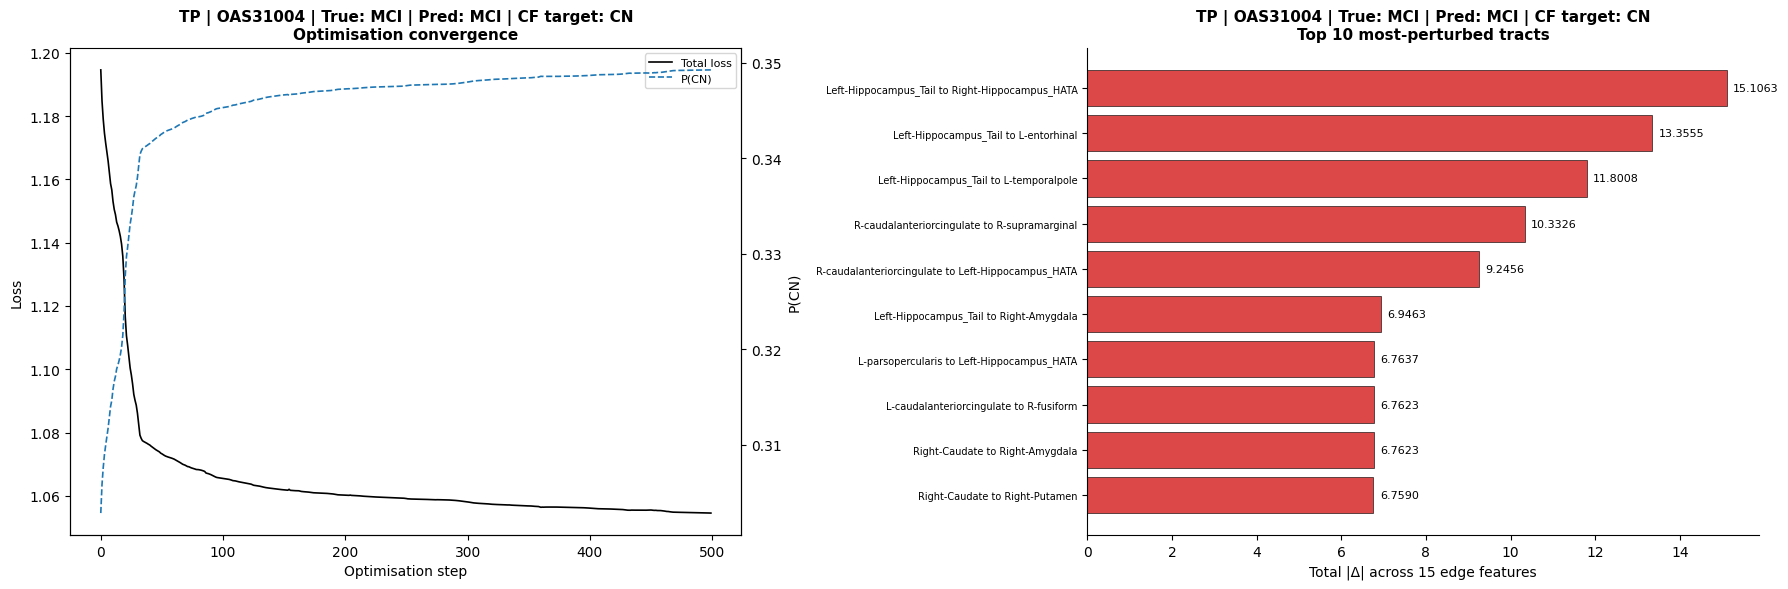

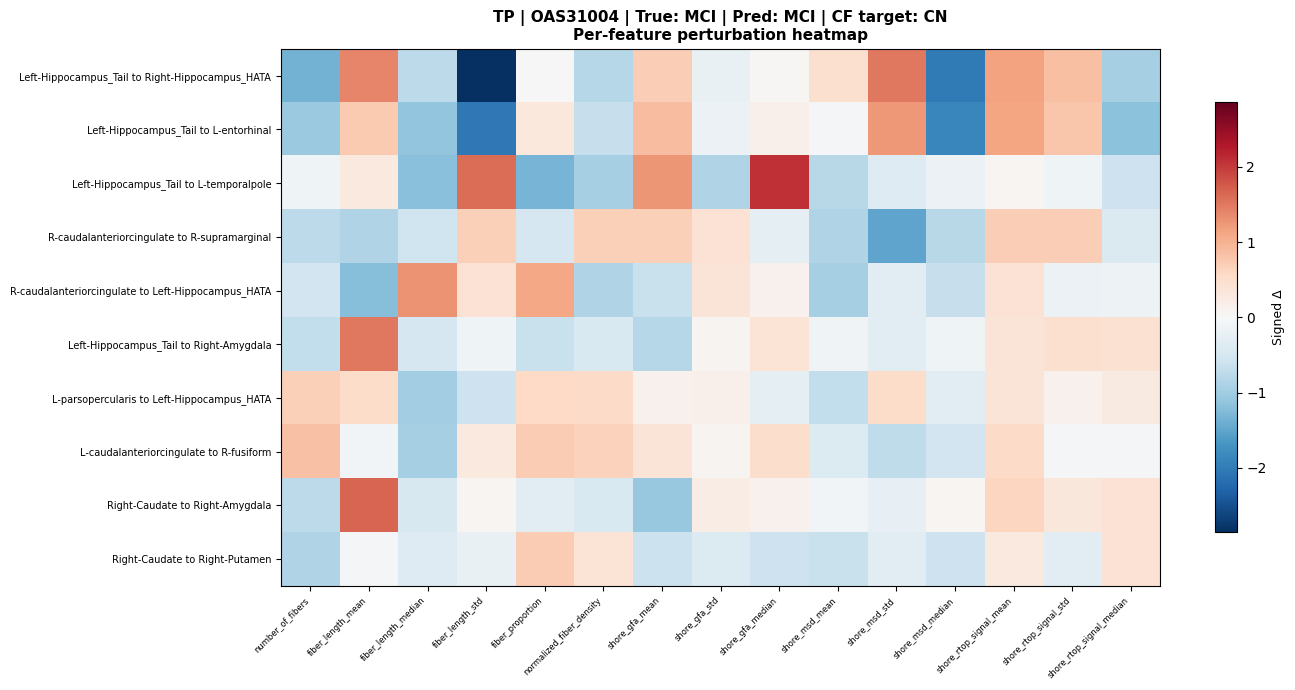


Edge CF - TN

Edge subgraph nodes (10):
  Right-Hippocampus, ctx-rh-fusiform, ctx-lh-posteriorcingulate, ctx-lh-inferiorparietal, ctx-lh-parahippocampal, ctx-rh-pericalcarine, ctx-lh-superiortemporal, ctx-lh-middletemporal, ctx-lh-fusiform, Right-Hippocampus_Hippocampal_fissure
  Selected edges: 1008 / 6268

TN | OAS30723 | True: CN | Pred: CN | CF target: MCI
  NOT FLIPPED in 500 steps
  Final P(MCI): 0.3003


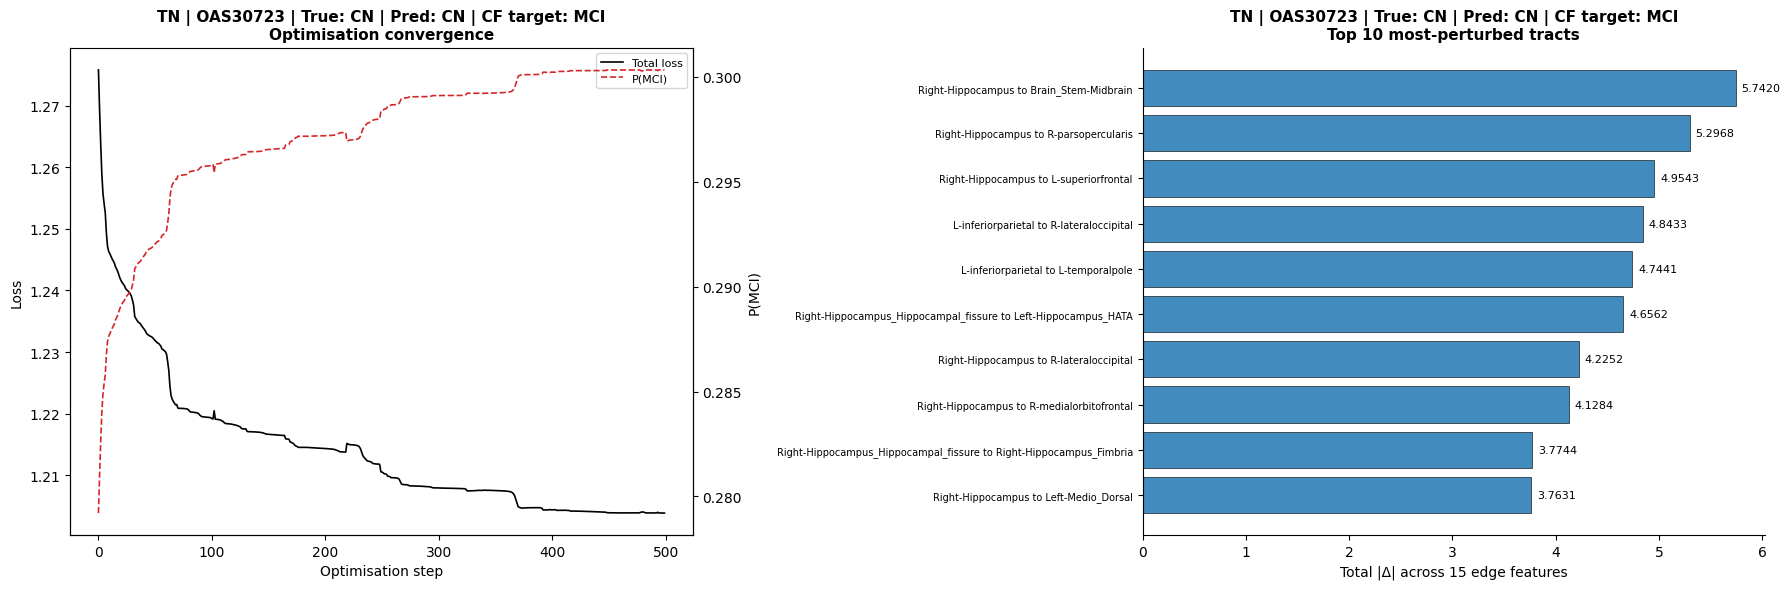

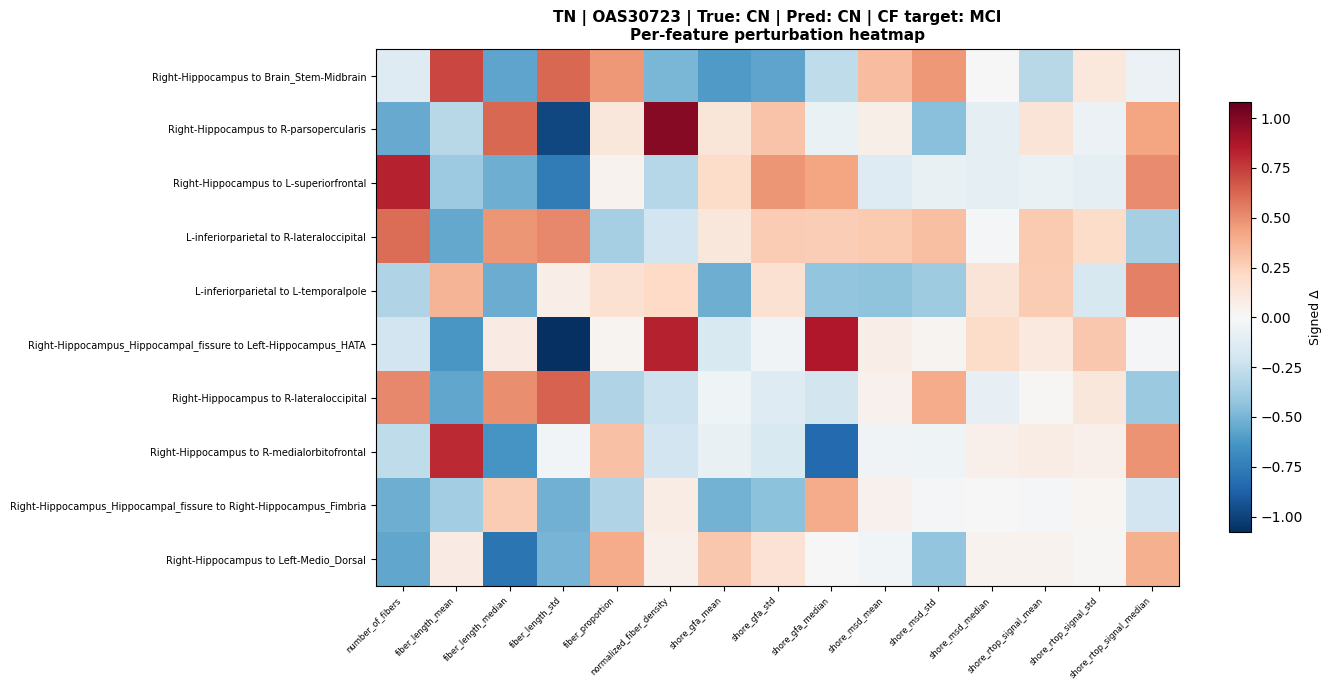


Edge CF - FP

Edge subgraph nodes (10):
  ctx-rh-rostralanteriorcingulate, Right-Caudate, ctx-rh-caudalanteriorcingulate, ctx-rh-posteriorcingulate, ctx-lh-caudalanteriorcingulate, Brain_Stem-Pons, ctx-lh-parsopercularis, Left-Pallidum, ctx-lh-isthmuscingulate, Left-Hippocampus_Tail
  Selected edges: 1110 / 5822

FP | OAS30443 | True: CN | Pred: MCI | CF target: CN
  NOT FLIPPED in 500 steps
  Final P(CN): 0.2340


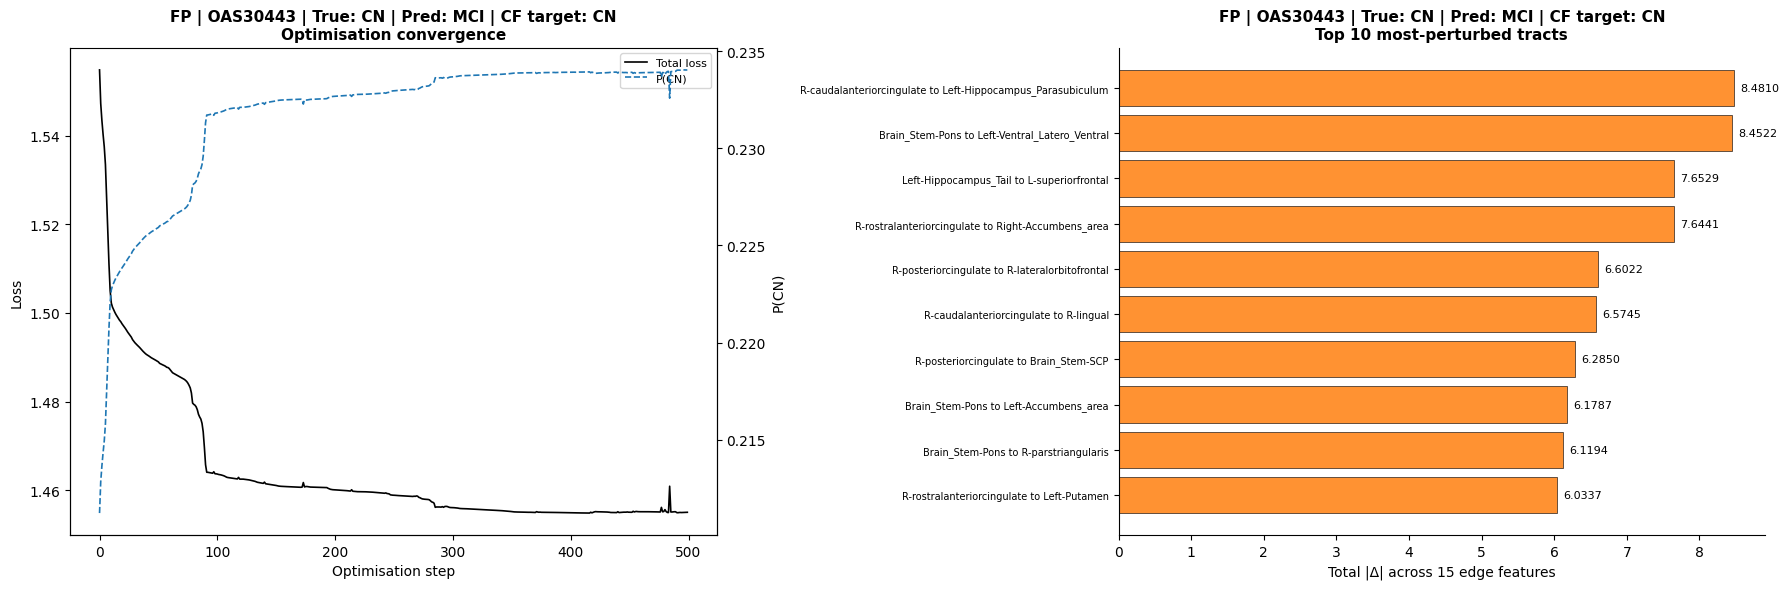

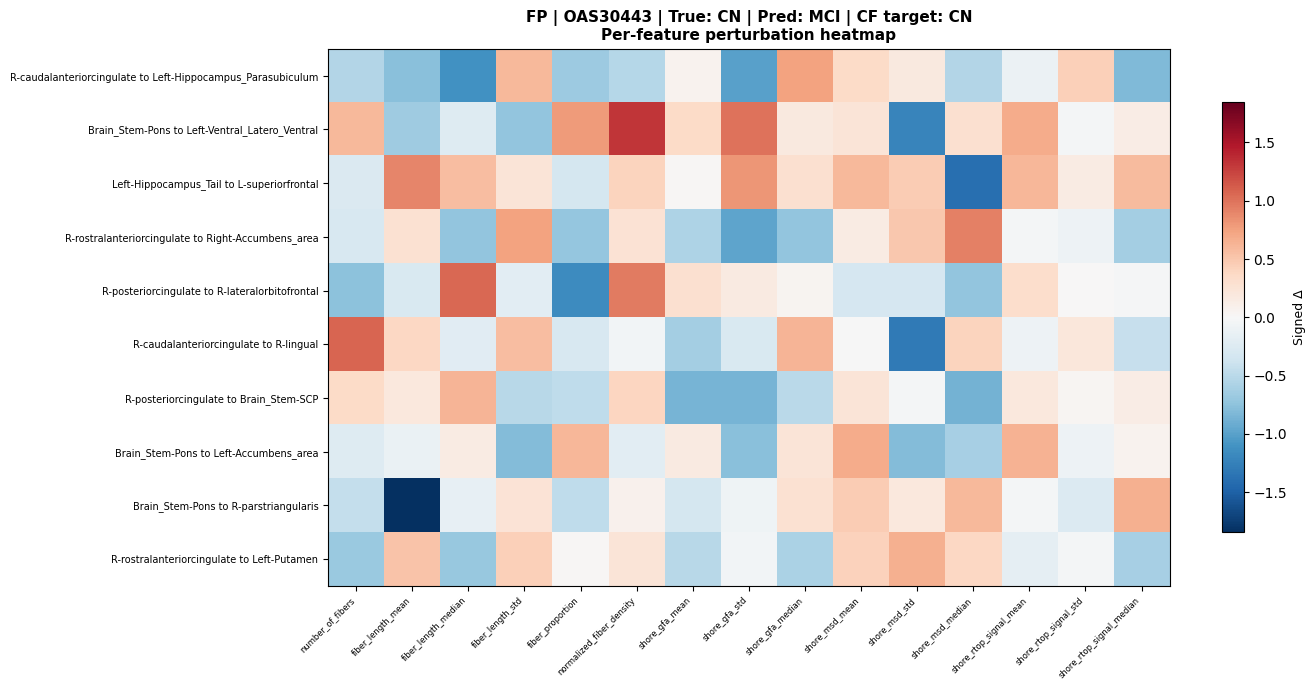


Edge CF - FN

Edge subgraph nodes (10):
  Right-Hippocampus, ctx-rh-fusiform, ctx-lh-posteriorcingulate, ctx-lh-inferiorparietal, ctx-lh-parahippocampal, ctx-rh-pericalcarine, ctx-lh-superiortemporal, ctx-lh-middletemporal, ctx-lh-fusiform, Right-Hippocampus_Hippocampal_fissure
  Selected edges: 1000 / 6276

FN | OAS31050 | True: MCI | Pred: CN | CF target: MCI
  NOT FLIPPED in 500 steps
  Final P(MCI): 0.4310


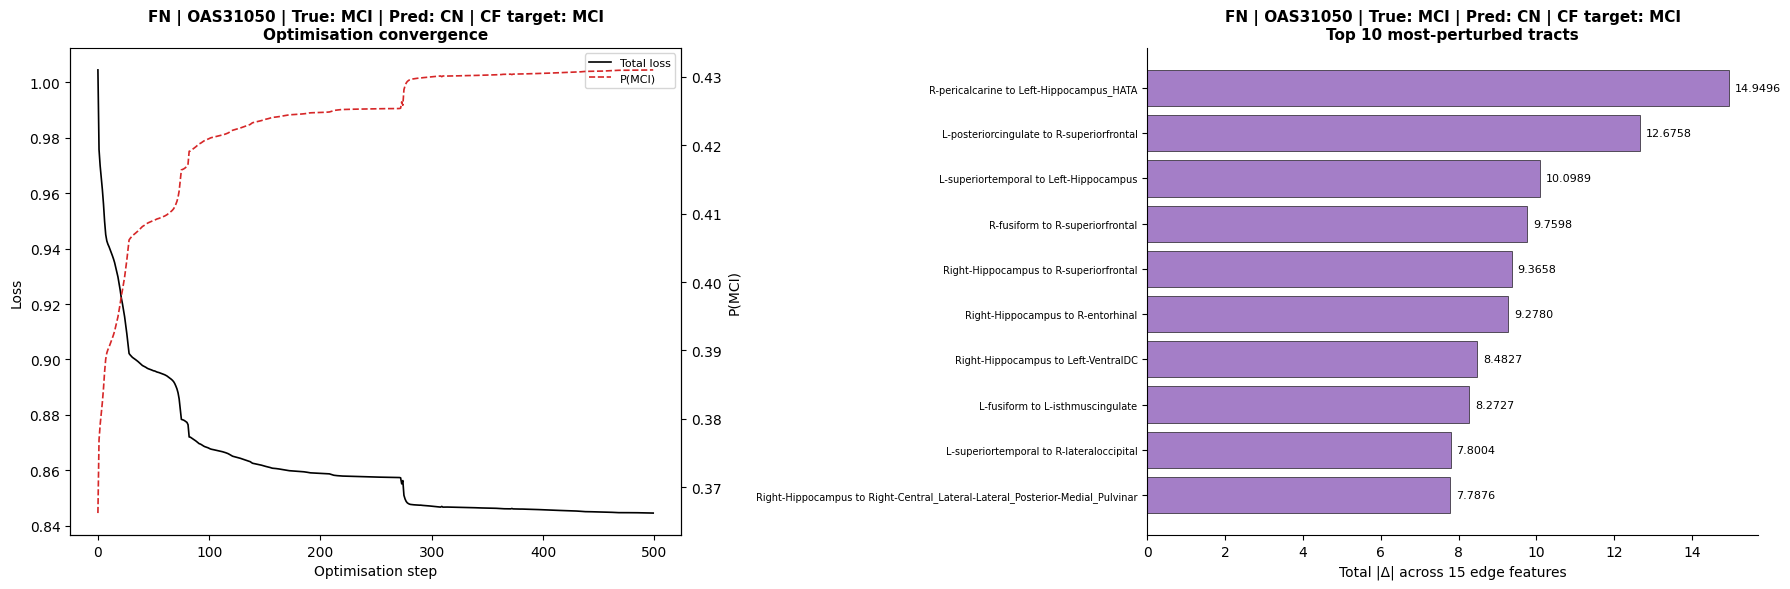

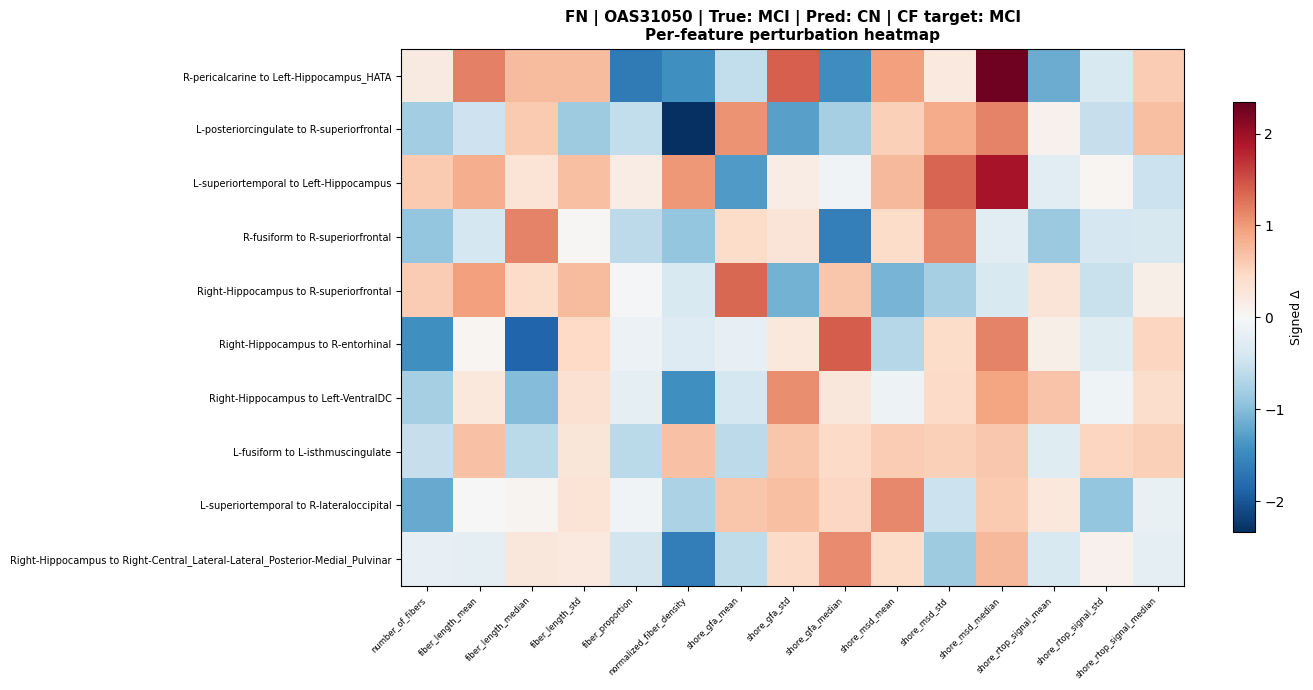

In [ ]:
def run_edge_single_subject(g, true_l, pred_l, tag, top_node_indices,
                             lambda_prox=0.1, lr=0.01, max_steps=500):
    target_class = 1 - pred_l

    print(f'\nEdge subgraph nodes ({len(top_node_indices)}):')
    print('  ' + ', '.join(node_labels[i] for i in sorted(top_node_indices)))

    edge_cf = run_edge_counterfactual(
        g, target_class, top_node_indices,
        lambda_prox=lambda_prox, lr=lr, max_steps=max_steps
    )

    flipped_str = 'FLIPPED' if edge_cf['flipped'] else 'NOT FLIPPED'
    title_base  = (f"{tag} | {g.subject_id} | "
                   f"True: {CLASS_NAMES[true_l]} | Pred: {CLASS_NAMES[pred_l]} | "
                   f"CF target: {CLASS_NAMES[target_class]}")
    print(f'\n{title_base}')
    print(f'  {flipped_str} in {edge_cf["steps"]} steps')
    print(f'  Final P({CLASS_NAMES[target_class]}): {edge_cf["prob_history"][-1]:.4f}')

    c = OUTCOME_COLORS[tag]

    # figure 1: convergence + top edge bar
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plot_convergence(axes[0], edge_cf['loss_history'], edge_cf['prob_history'],
                     target_class, f'{title_base}\nOptimisation convergence')
    plot_edge_delta_bar(axes[1], edge_cf, g.edge_index,
                        f'{title_base}\nTop 10 most-perturbed tracts', c)
    plt.tight_layout()
    plt.show()

    # figure 2: per-feature heatmap
    fig, ax = plt.subplots(figsize=(14, 7))
    plot_edge_feature_heatmap(ax, edge_cf, g.edge_index,
                              f'{title_base}\nPer-feature perturbation heatmap')
    plt.tight_layout()
    plt.show()

    return edge_cf


edge_case_results = {}
for tag in ['TP', 'TN', 'FP', 'FN']:
    if tag not in node_case_results:
        print(f'{tag}: no node CF result, skipping.')
        continue

    data   = node_case_results[tag]
    g      = data['graph']
    pred_l = data['pred']
    true_l = data['true']

    # select the correct fixed subgraph based on predicted class
    top_nodes = top_nodes_mci_pred if pred_l == 1 else top_nodes_cn_pred

    print(f'\n{"="*60}\nEdge CF - {tag}')
    edge_cf = run_edge_single_subject(g, true_l, pred_l, tag, top_nodes)
    edge_case_results[tag] = {'graph': g, 'true': true_l, 'pred': pred_l, 'edge_cf': edge_cf}

### Population analysis per outcome group

In [ ]:
def run_edge_cf_population(result_pool, pred_label, tag, top_node_indices,
                            lambda_prox=0.1, lr=0.01, max_steps=500):
    '''
    Runs edge CF on every subject in result_pool using the shared top_node_indices
    Node CF results are looked up from node_subject_cfs

    Returns
    mean_feat_delta : (15,) mean |Δ| per edge feature across population
    flip_rate       : float
    '''
    target_class   = 1 - pred_label
    all_feat_delta = []
    flip_count     = 0

    for g, true, pred, _ in result_pool:
        edge_cf = run_edge_counterfactual(
            g, target_class, top_node_indices,
            lambda_prox=lambda_prox, lr=lr, max_steps=max_steps
        )
        # mean |Δ| per feature across selected edges for this subject
        feat_delta = np.abs(edge_cf['delta']).mean(axis=0)   # (15,)
        all_feat_delta.append(feat_delta)
        if edge_cf['flipped']:
            flip_count += 1

    mean_feat_delta = np.stack(all_feat_delta).mean(axis=0)
    flip_rate       = flip_count / len(result_pool)
    print(f'{tag} (n={len(result_pool)}): edge CF flip rate = {flip_rate:.2%}')
    return mean_feat_delta, flip_rate


edge_pop_results = {}
for tag, pool, pred_l in [('TP', TP, 1), ('TN', TN, 0), ('FP', FP, 1), ('FN', FN, 0)]:
    if not pool:
        print(f'{tag}: no subjects, skipping.')
        continue
    top_nodes = top_nodes_mci_pred if pred_l == 1 else top_nodes_cn_pred
    mean_feat_delta, flip_rate = run_edge_cf_population(pool, pred_l, tag, top_nodes)
    edge_pop_results[tag] = {'mean_feat_delta': mean_feat_delta, 'flip_rate': flip_rate, 'n': len(pool)}

  Selected edges: 1218 / 5492
  Selected edges: 880 / 5736
  Selected edges: 1092 / 5580
  Selected edges: 1102 / 5680
  Selected edges: 970 / 4702
  Selected edges: 1094 / 5516
  Selected edges: 1106 / 6012
  Selected edges: 1006 / 5480
  Selected edges: 1206 / 6074
  Selected edges: 1070 / 6184
  Selected edges: 1126 / 6234
  Selected edges: 1270 / 5802
  Selected edges: 1108 / 6536
  Selected edges: 1198 / 5994
TP (n=14): edge CF flip rate = 42.86%
  Selected edges: 1008 / 6268
  Selected edges: 1018 / 6288
  Selected edges: 886 / 6140
  Selected edges: 808 / 5898
  Selected edges: 1012 / 6366
  Selected edges: 928 / 6210
  Selected edges: 856 / 5704
  Selected edges: 910 / 5888
  Selected edges: 1042 / 6322
  Selected edges: 982 / 6536
  Selected edges: 990 / 5982
  Selected edges: 1030 / 6686
  Selected edges: 952 / 5930
  Selected edges: 956 / 6412
  Selected edges: 960 / 5680
  Selected edges: 940 / 6282
  Selected edges: 854 / 5986
  Selected edges: 752 / 5912
  Selected edges:

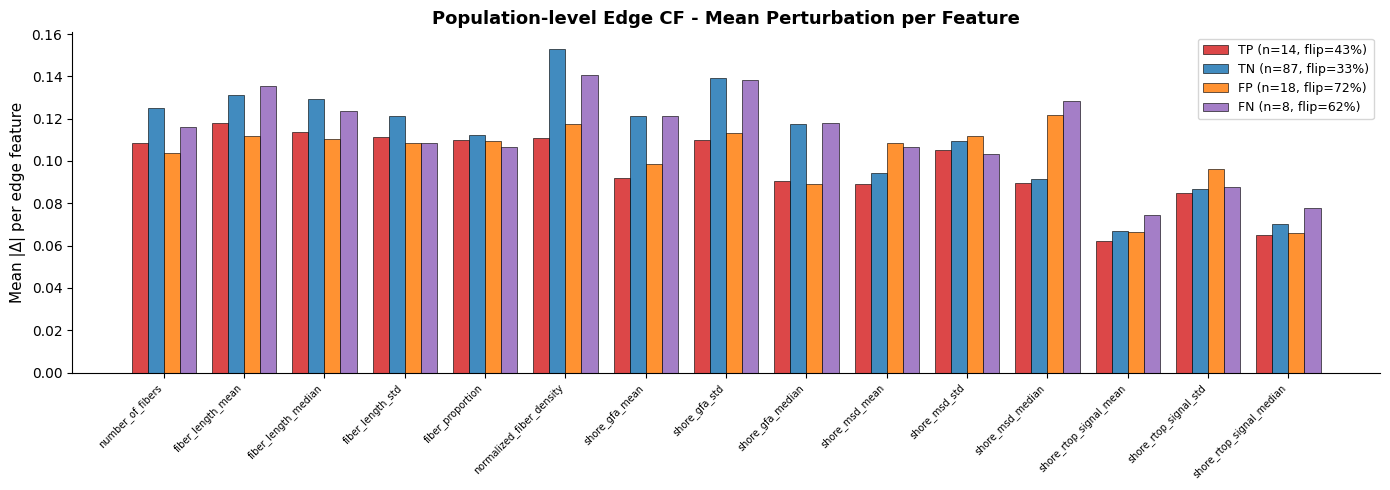

In [ ]:
# grouped bar chart: mean |Δ| per edge feature, one bar cluster per outcome
available_tags = [t for t in ['TP', 'TN', 'FP', 'FN'] if t in edge_pop_results]
x     = np.arange(15)
width = 0.8 / len(available_tags)

fig, ax = plt.subplots(figsize=(14, 5))
for i, tag in enumerate(available_tags):
    r      = edge_pop_results[tag]
    offset = (i - len(available_tags) / 2 + 0.5) * width
    ax.bar(x + offset, r['mean_feat_delta'], width,
           label=f"{tag} (n={r['n']}, flip={r['flip_rate']:.0%})",
           color=OUTCOME_COLORS[tag], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(EDGE_FEATURE_NAMES, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Mean |Δ| per edge feature', fontsize=11)
ax.set_title('Population-level Edge CF - Mean Perturbation per Feature',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Flip rate summary for both counterfactuals

In [ ]:
print(f'{"Outcome":<8}  {"N":>4}  {"Node CF flip":>14}  {"Edge CF flip":>14}')
print('-' * 46)
for tag in ['TP', 'TN', 'FP', 'FN']:
    n_flip = node_pop_results.get(tag, {}).get('flip_rate', float('nan'))
    e_flip = edge_pop_results.get(tag, {}).get('flip_rate', float('nan'))
    n      = node_pop_results.get(tag, edge_pop_results.get(tag, {})).get('n', '—')
    print(f'{tag:<8}  {str(n):>4}  {n_flip:>13.2%}  {e_flip:>13.2%}')

Outcome      N    Node CF flip    Edge CF flip
----------------------------------------------
TP          14        100.00%         42.86%
TN          87        100.00%         33.33%
FP          18        100.00%         72.22%
FN           8        100.00%         62.50%


### Population analysis per predicted class and per real class

In [ ]:
# class-level pools sliced two ways
class_pools_true = {
    'CN':  ('CN-true',  TN + FP, 0),   # pred_label here = 1 - target = original pred for flip direction is mixed
    'MCI': ('MCI-true', TP + FN, 1),
}
class_pools_pred = {
    'CN':  ('CN-pred',  TN + FN, 0),
    'MCI': ('MCI-pred', TP + FP, 1),
}

CLASS_COLORS = {'CN': '#1f77b4', 'MCI': '#d62728'}


def aggregate_class_pool(pool, node_subject_cfs):
    '''
    Aggregates pre-computed node CF results for a class pool

    Returns
    mean_delta_mag : (num_nodes,) mean of |Δ_volume| + |Δ_thickness| per node
    mean_delta_signed_mci : (num_nodes, 2) mean signed MCI-contribution per
                            node for [volume, thickness]. Positive => feature
                            pushes the model toward MCI; negative => toward CN
    flip_rate : fraction of subjects whose prediction flipped
    n         : pool size
    '''
    mags, signed_mci, flips = [], [], 0
    for g, true, pred, _ in pool:
        cf = node_subject_cfs[g.subject_id]
        delta = cf['delta']                       # (num_nodes, 4); cols 0-1 = vol, thick
        mags.append(node_delta_magnitude(delta))  # |Δv| + |Δt|

        # MCI-contribution sign:
        #   pred=MCI (1) => CF moves toward CN, so original feature value pushed
        #                   toward MCI; flip the sign of delta
        #   pred=CN  (0) => CF moves toward MCI, delta already in MCI direction
        sign = 1.0 if pred == 0 else -1.0
        signed_mci.append(sign * delta[:, :2])    # (num_nodes, 2)

        if cf['flipped']:
            flips += 1

    return {
        'mean_delta_mag'        : np.stack(mags).mean(axis=0),
        'mean_delta_signed_mci' : np.stack(signed_mci).mean(axis=0),
        'flip_rate'             : flips / len(pool),
        'n'                     : len(pool),
    }


node_class_results_true = {}
node_class_results_pred = {}

for cls, (tag, pool, _) in class_pools_true.items():
    if not pool:
        print(f'{tag}: empty pool, skipping.')
        continue
    node_class_results_true[cls] = aggregate_class_pool(pool, node_subject_cfs)
    r = node_class_results_true[cls]
    print(f'{tag:<8} (n={r["n"]:>3}): flip rate = {r["flip_rate"]:.2%}')

print()
for cls, (tag, pool, _) in class_pools_pred.items():
    if not pool:
        print(f'{tag}: empty pool, skipping.')
        continue
    node_class_results_pred[cls] = aggregate_class_pool(pool, node_subject_cfs)
    r = node_class_results_pred[cls]
    print(f'{tag:<8} (n={r["n"]:>3}): flip rate = {r["flip_rate"]:.2%}')

CN-true  (n=105): flip rate = 100.00%
MCI-true (n= 22): flip rate = 100.00%

CN-pred  (n= 95): flip rate = 100.00%
MCI-pred (n= 32): flip rate = 100.00%


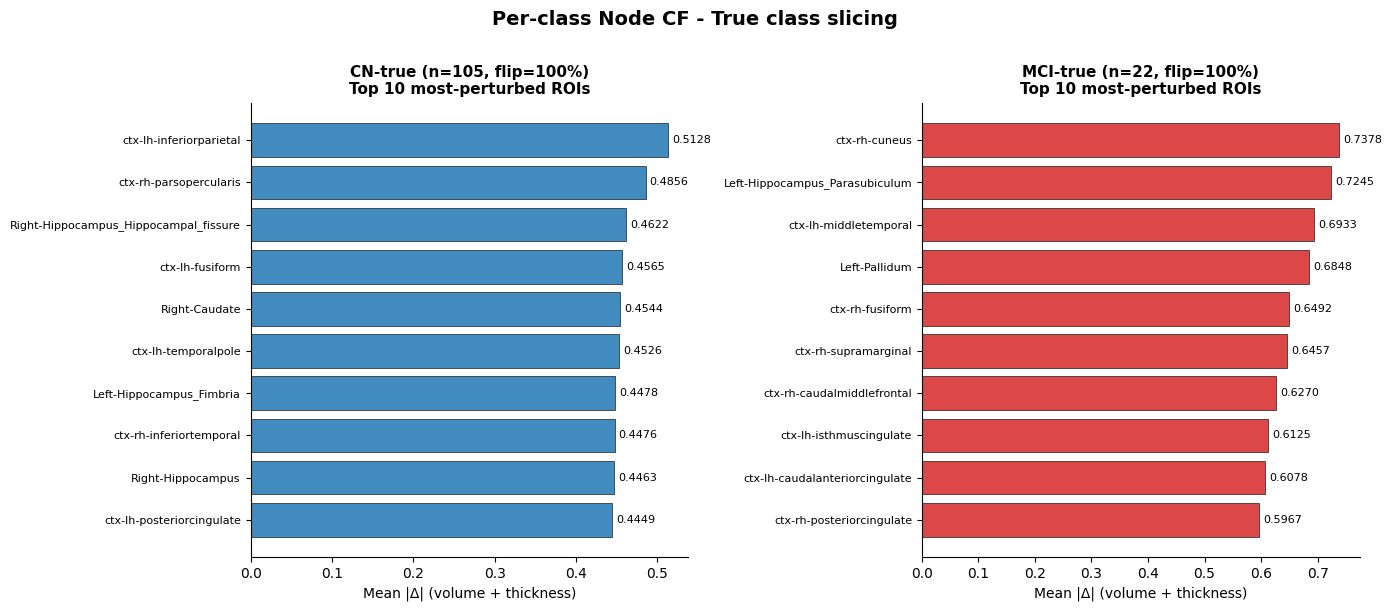

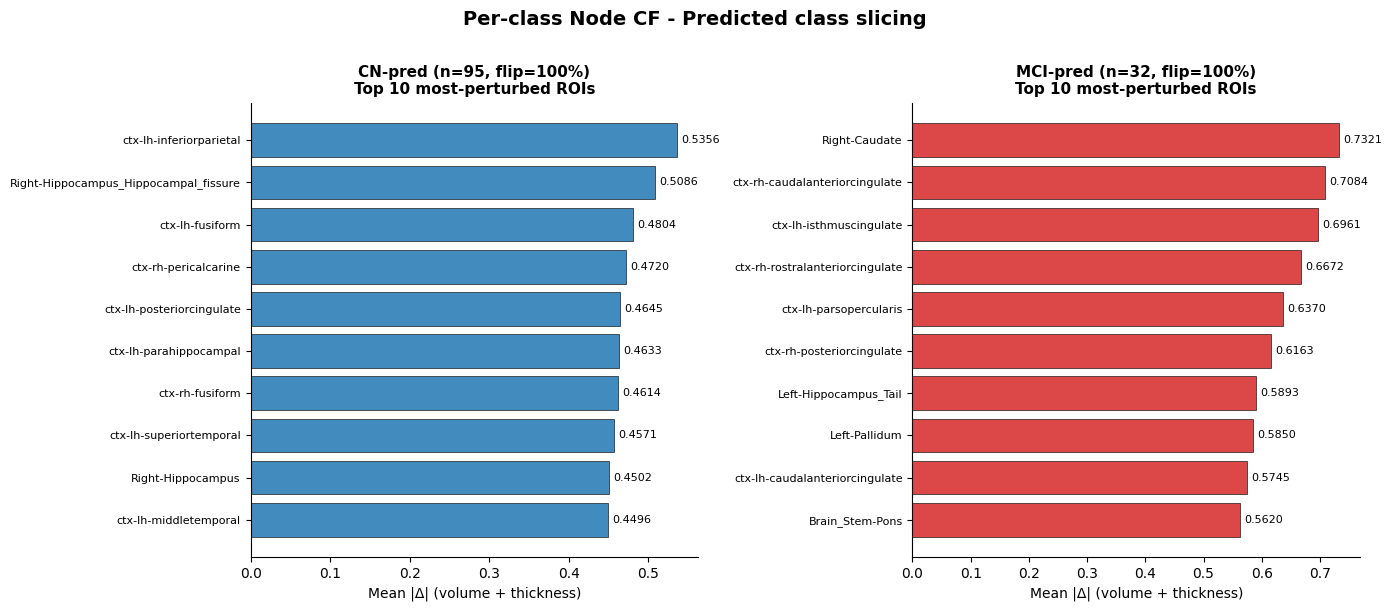

In [ ]:
# Top-10 most-perturbed ROIs per class (magnitude-based) - by true class and by predicted class

def plot_class_top_roi_bar(ax, mean_delta_mag, title, color, top_n=10):
    top_idx    = np.argsort(mean_delta_mag)[::-1][:top_n]
    top_scores = mean_delta_mag[top_idx]
    top_names  = [node_labels[i] for i in top_idx]
    names_r, scores_r = list(top_names[::-1]), list(top_scores[::-1])
    bars = ax.barh(names_r, scores_r, color=color, alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Mean |Δ| (volume + thickness)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    for bar, score in zip(bars, scores_r):
        ax.text(bar.get_width() + max(scores_r) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=8)


for slicing_name, results, pool_map in [
    ('True class',      node_class_results_true, class_pools_true),
    ('Predicted class', node_class_results_pred, class_pools_pred),
]:
    available = [c for c in ['CN', 'MCI'] if c in results]
    if not available:
        continue
    fig, axes = plt.subplots(1, len(available), figsize=(7 * len(available), 6))
    if len(available) == 1:
        axes = [axes]
    for ax, cls in zip(axes, available):
        r   = results[cls]
        tag = pool_map[cls][0]
        plot_class_top_roi_bar(
            ax, r['mean_delta_mag'],
            f'{tag} (n={r["n"]}, flip={r["flip_rate"]:.0%})\nTop 10 most-perturbed ROIs',
            CLASS_COLORS[cls],
        )
    plt.suptitle(f'Per-class Node CF - {slicing_name} slicing',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

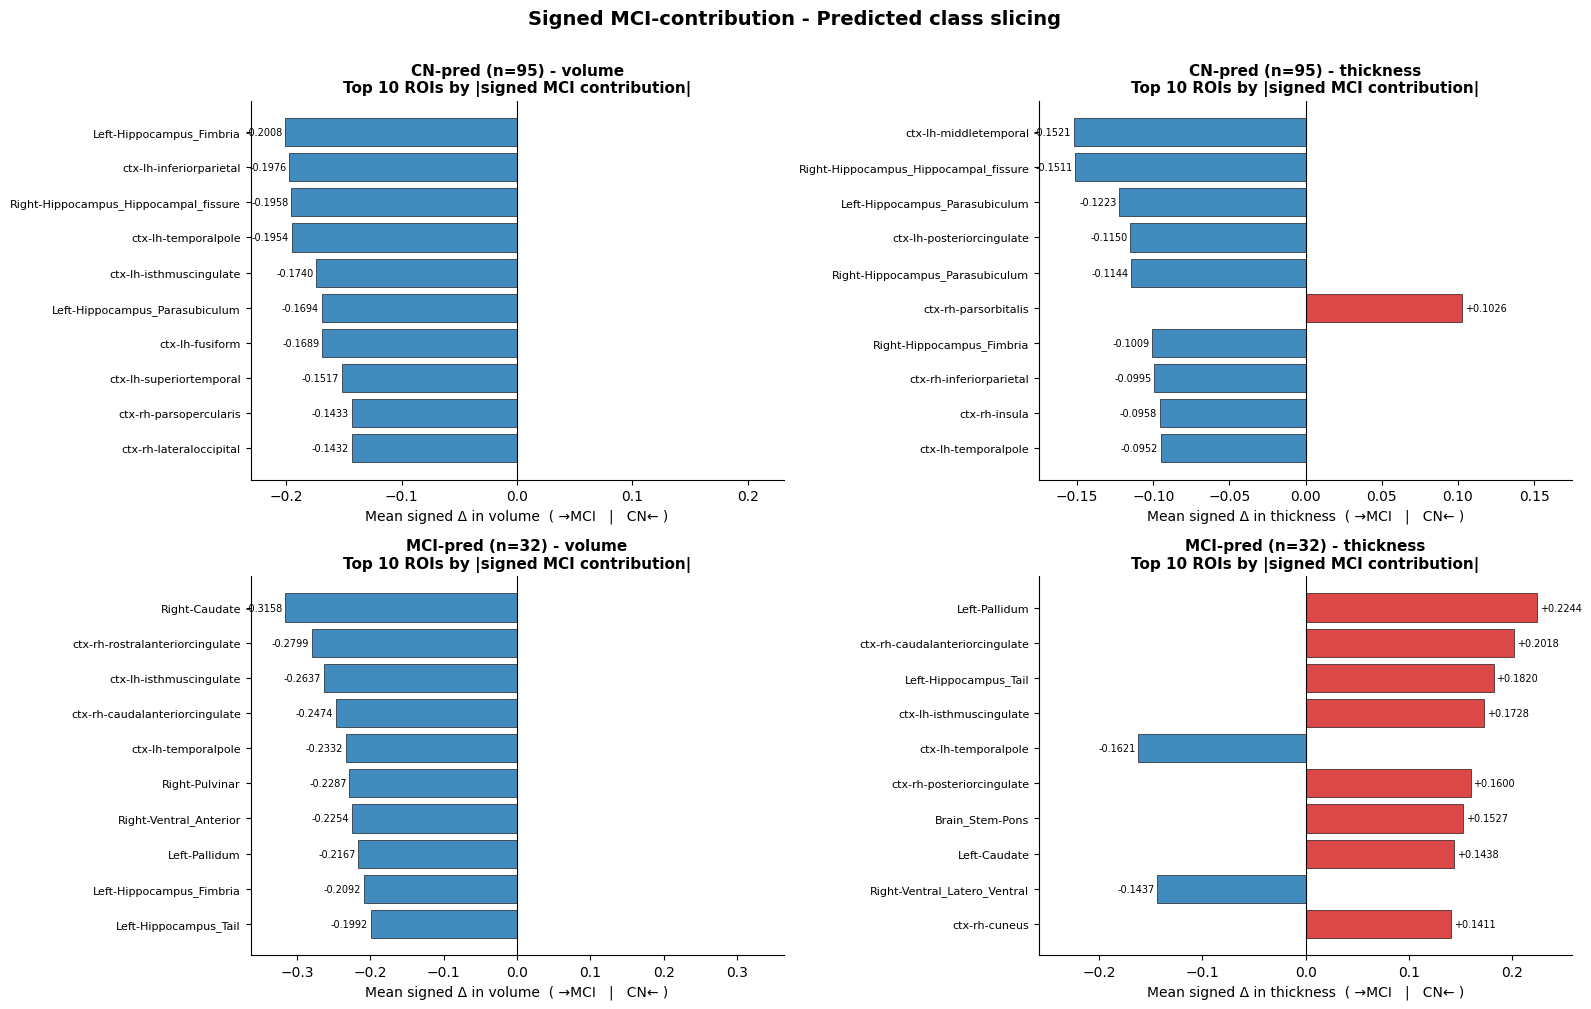

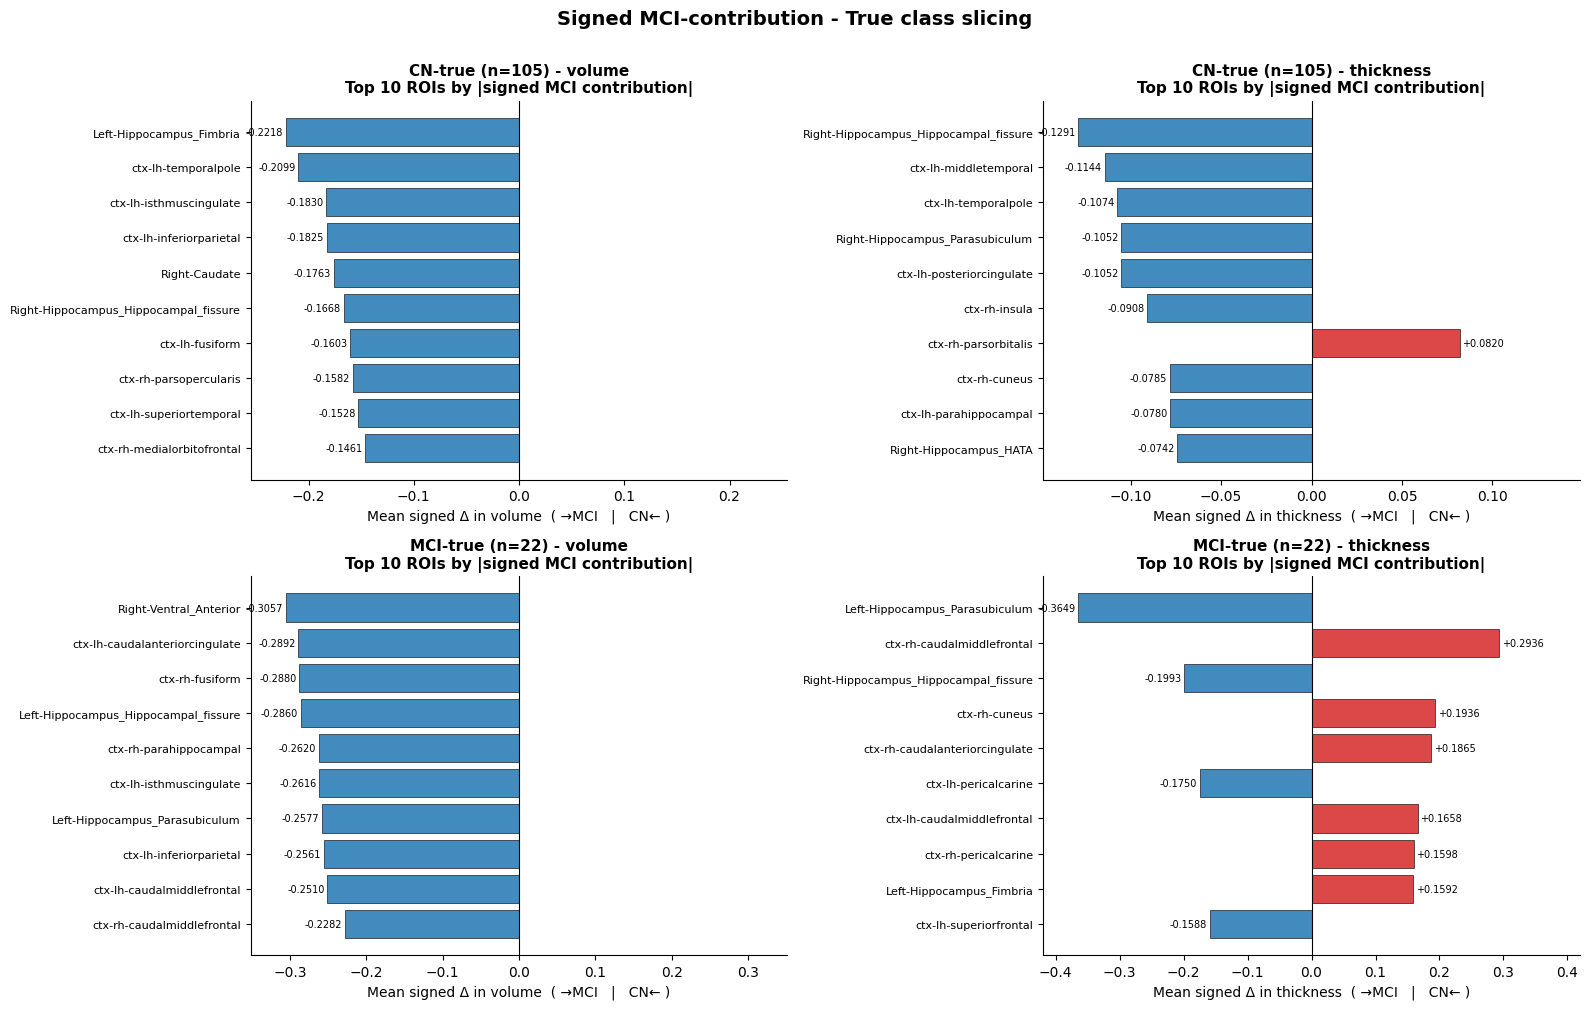

In [ ]:
def plot_signed_diverging(ax, signed_mci, feat_idx, feat_name, color_pro, color_anti, top_n=10):
    '''
    Diverging horizontal bar chart: top_n nodes by |signed| MCI-contribution
    Red bars to the right => pushes toward MCI; blue to the left => pushes toward CN
    '''
    vals    = signed_mci[:, feat_idx]                  # (num_nodes,)
    rank    = np.argsort(np.abs(vals))[::-1][:top_n]
    sub     = vals[rank]
    names   = [node_labels[i] for i in rank]

    # plot bottom-up so most influential is at the top
    names_r, vals_r = list(names[::-1]), list(sub[::-1])
    colors = [color_pro if v >= 0 else color_anti for v in vals_r]
    bars   = ax.barh(names_r, vals_r, color=colors, alpha=0.85,
                     edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'Mean signed Δ in {feat_name}  ( →MCI   |   CN← )', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    xmax = max(abs(min(vals_r)), abs(max(vals_r))) * 1.15
    ax.set_xlim(-xmax, xmax)
    for bar, v in zip(bars, vals_r):
        offset = xmax * 0.01
        x_text = bar.get_width() + (offset if v >= 0 else -offset)
        ha     = 'left' if v >= 0 else 'right'
        ax.text(x_text, bar.get_y() + bar.get_height() / 2,
                f'{v:+.4f}', va='center', ha=ha, fontsize=7)


PERTURBED_FEATURES = [(0, 'volume'), (1, 'thickness')]
PRO_MCI_COLOR  = '#d62728'
ANTI_MCI_COLOR = '#1f77b4'

# one figure per class slicing
for slicing_name, results, pool_map in [
    ('Predicted class', node_class_results_pred, class_pools_pred),
    ('True class',      node_class_results_true, class_pools_true),
]:
    available = [c for c in ['CN', 'MCI'] if c in results]
    if not available:
        continue
    fig, axes = plt.subplots(len(available), len(PERTURBED_FEATURES),
                             figsize=(8 * len(PERTURBED_FEATURES), 5 * len(available)))
    if len(available) == 1:
        axes = np.array([axes])
    if len(PERTURBED_FEATURES) == 1:
        axes = axes.reshape(-1, 1)

    for row, cls in enumerate(available):
        r   = results[cls]
        tag = pool_map[cls][0]
        for col, (fidx, fname) in enumerate(PERTURBED_FEATURES):
            ax = axes[row, col]
            plot_signed_diverging(
                ax, r['mean_delta_signed_mci'], fidx, fname,
                PRO_MCI_COLOR, ANTI_MCI_COLOR,
            )
            ax.set_title(f'{tag} (n={r["n"]}) - {fname}\nTop 10 ROIs by |signed MCI contribution|',
                         fontsize=11, fontweight='bold')

    plt.suptitle(f'Signed MCI-contribution - {slicing_name} slicing',
                 fontsize=14, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.show()

In [ ]:
# print top pro-MCI and pro-CN ROIs per class (predicted-class slicing)
def print_signed_top(results, pool_map, slicing_name, top_n=10):
    print(f'\n{"="*72}')
    print(f'Signed MCI-contribution ranking - {slicing_name}')
    print(f'{"="*72}')
    for cls in ['CN', 'MCI']:
        if cls not in results:
            continue
        r   = results[cls]
        tag = pool_map[cls][0]
        for fidx, fname in PERTURBED_FEATURES:
            vals = r['mean_delta_signed_mci'][:, fidx]
            pro_idx  = np.argsort(vals)[::-1][:top_n]   # most positive
            anti_idx = np.argsort(vals)[:top_n]         # most negative
            print(f'\n  {tag}  |  feature: {fname}')
            print(f'    Top {top_n} PRO-MCI (positive => pushes to MCI):')
            for rank, i in enumerate(pro_idx, 1):
                print(f'      {rank:02d}. {node_labels[i]:<45s}  {vals[i]:+.6f}')
            print(f'    Top {top_n} ANTI-MCI / PRO-CN (negative => pushes to CN):')
            for rank, i in enumerate(anti_idx, 1):
                print(f'      {rank:02d}. {node_labels[i]:<45s}  {vals[i]:+.6f}')


print_signed_top(node_class_results_pred, class_pools_pred, 'Predicted class')
print_signed_top(node_class_results_true, class_pools_true, 'True class')


# per-class summary tables: flip rates aggregated from existing outcome-level results
def aggregate_outcome_to_class_flip(outcome_results, outcome_map):
    '''
    outcome_map: {class_label: [list of outcome tags that fall under it]}
    Returns dict {class_label: (n, weighted_flip_rate)}
    '''
    out = {}
    for cls, tags in outcome_map.items():
        n_total, n_flipped = 0, 0
        for tag in tags:
            if tag not in outcome_results:
                continue
            n = outcome_results[tag]['n']
            n_total   += n
            n_flipped += n * outcome_results[tag]['flip_rate']
        if n_total > 0:
            out[cls] = (n_total, n_flipped / n_total)
    return out


# node CF flip rates already aggregated in node_class_results_*; just print
# edge CF flip rates: aggregate from edge_pop_results by class
edge_class_true = aggregate_outcome_to_class_flip(
    edge_pop_results, {'CN': ['TN', 'FP'], 'MCI': ['TP', 'FN']})
edge_class_pred = aggregate_outcome_to_class_flip(
    edge_pop_results, {'CN': ['TN', 'FN'], 'MCI': ['TP', 'FP']})

print(f'\n{"="*72}')
print('Per-class flip-rate summary')
print(f'{"="*72}')
print(f'{"Slicing":<18}  {"Class":<6}  {"N":>4}  {"Node CF flip":>14}  {"Edge CF flip":>14}')
print('-' * 64)
for cls in ['CN', 'MCI']:
    if cls in node_class_results_true:
        nr = node_class_results_true[cls]
        ef = edge_class_true.get(cls, (nr['n'], float('nan')))[1]
        print(f'{"True class":<18}  {cls:<6}  {nr["n"]:>4}  '
              f'{nr["flip_rate"]:>13.2%}  {ef:>13.2%}')
for cls in ['CN', 'MCI']:
    if cls in node_class_results_pred:
        nr = node_class_results_pred[cls]
        ef = edge_class_pred.get(cls, (nr['n'], float('nan')))[1]
        print(f'{"Predicted class":<18}  {cls:<6}  {nr["n"]:>4}  '
              f'{nr["flip_rate"]:>13.2%}  {ef:>13.2%}')


Signed MCI-contribution ranking - Predicted class

  CN-pred  |  feature: volume
    Top 10 PRO-MCI (positive => pushes to MCI):
      01. ctx-rh-parsorbitalis                           +0.002343
      02. Right-Hippocampus_Presubiculum                 +0.002094
      03. Right-Hippocampus_CA1                          +0.001945
      04. Left-Hippocampus_CA4                           +0.001907
      05. Left-Hippocampus_CA3                           +0.001907
      06. Left-Hippocampus_CA1                           +0.001907
      07. Left-Hippocampus_Presubiculum                  +0.001907
      08. Left-Hippocampus_Subiculum                     +0.001907
      09. Right-Hippocampus_Molecular_layer_HP           +0.001907
      10. Right-Hippocampus_GCDG                         +0.001907
    Top 10 ANTI-MCI / PRO-CN (negative => pushes to CN):
      01. Left-Hippocampus_Fimbria                       -0.200838
      02. ctx-lh-inferiorparietal                        -0.197635
      03.